<a href="https://colab.research.google.com/github/kelesmerve/iomt-ortaminda-federe-ogrenme-bitirme-projesi/blob/main/federe_mha_10client.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 1: ORTAM KURULUMU VE H100 YAPILANDIRMASI
# =============================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import mixed_precision
from google.colab import drive

print("=" * 65)
print("   FEDERE MHA-LSTM EĞİTİMİ — H100 ORTAM BAŞLATILIYOR (10 CLIENT)")
print("=" * 65)

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
print("✅ Google Drive bağlandı.")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU Aktif: {len(gpus)} adet")
        for i, gpu in enumerate(gpus):
            details = tf.config.experimental.get_device_details(gpu)
            print(f"   -> GPU {i}: {details.get('device_name', 'Bilinmiyor')}")
    except RuntimeError as e:
        print(f"⚠️ GPU Ayar Hatası: {e}")
else:
    print("⚠️ GPU Bulunamadı!")

mixed_precision.set_global_policy('mixed_bfloat16')
print(f"✅ Mixed Precision: {mixed_precision.global_policy().name}")

tf.config.optimizer.set_jit(True)
print("✅ XLA JIT Derleme: AKTİF")

# -----------------------------------------------------------------------------
# GLOBAL SABİTLER
# -----------------------------------------------------------------------------
ROOT_PATH      = '/content/drive/MyDrive/wifi_mqtt'

# Veri
TIME_STEPS     = 20
TEST_SIZE      = 0.20
PCA_VARIANCE   = 0.95
SEED           = 42

# Federe Eğitim
NUM_CLIENTS    = 10      # 5 → 10
ROUNDS         = 50
LOCAL_EPOCHS   = 8
BATCH_SIZE     = 512
LEARNING_RATE  = 0.001

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("\n📋 GÜNCEL GLOBAL SABİTLER:")
print(f"   ROOT_PATH      : {ROOT_PATH}")
print(f"   TIME_STEPS     : {TIME_STEPS}")
print(f"   PCA_VARIANCE   : %{PCA_VARIANCE*100:.0f}")
print(f"   BATCH_SIZE     : {BATCH_SIZE}")
print(f"   NUM_CLIENTS    : {NUM_CLIENTS}  ← 5'ten 10'a")
print(f"   FEDERE ROUNDS  : {ROUNDS}")
print(f"   LOCAL_EPOCHS   : {LOCAL_EPOCHS}")
print(f"   LEARNING_RATE  : {LEARNING_RATE}")

print(f"\n✅ TensorFlow : {tf.__version__}")
print(f"✅ NumPy      : {np.__version__}")
print("\n" + "=" * 65)
print("   ORTAM HAZIR — HÜCRE 2'YE GEÇEBİLİRSİNİZ")
print("=" * 65)

   FEDERE MHA-LSTM EĞİTİMİ — H100 ORTAM BAŞLATILIYOR (10 CLIENT)
✅ Google Drive bağlandı.
✅ GPU Aktif: 1 adet
   -> GPU 0: NVIDIA A100-SXM4-40GB
✅ Mixed Precision: mixed_bfloat16
✅ XLA JIT Derleme: AKTİF

📋 GÜNCEL GLOBAL SABİTLER:
   ROOT_PATH      : /content/drive/MyDrive/wifi_mqtt
   TIME_STEPS     : 20
   PCA_VARIANCE   : %95
   BATCH_SIZE     : 512
   NUM_CLIENTS    : 10  ← 5'ten 10'a
   FEDERE ROUNDS  : 50
   LOCAL_EPOCHS   : 8
   LEARNING_RATE  : 0.001

✅ TensorFlow : 2.20.0
✅ NumPy      : 2.0.2

   ORTAM HAZIR — HÜCRE 2'YE GEÇEBİLİRSİNİZ


   VERİ HAZIRLAMA AŞAMASI BAŞLATILIYOR

📂 Normal (Profiling) dosyaları taranıyor...
   -> Bulunan toplam dosya: 42

⏳ Dosyalar yükleniyor...
   -> Ham veri boyutu: (389956, 45)

🧹 Veri temizleniyor...
   -> Silinen sabit kolonlar (5 adet): ['Drate', 'Telnet', 'SMTP', 'SSH', 'IRC']
   -> Temizleme sonrası boyut: (389956, 40)
   -> Kullanılacak özellik sayısı: 40

⚖️ Global StandardScaler uygulanıyor...
   -> Global scaler kaydedildi: federe_mha_scaler.pkl

🔬 PCA Varyans Analizi yapılıyor (Hedef: %95)...
   -> %95 varyans için gereken bileşen sayısı: 20


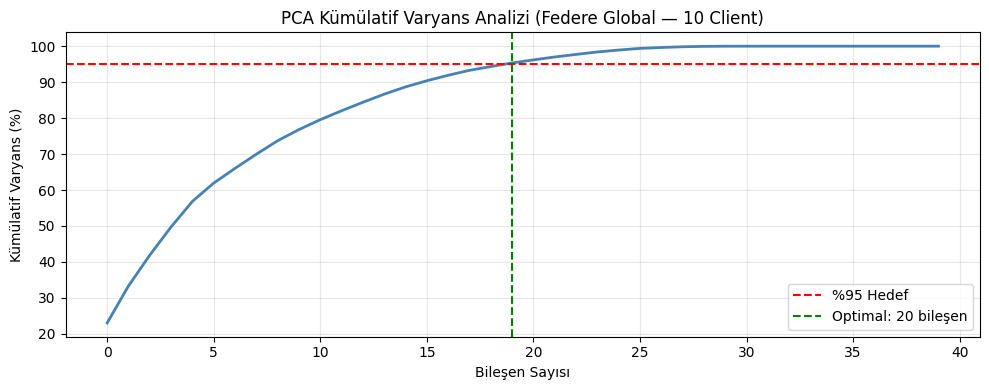

   -> Global PCA kaydedildi: federe_mha_pca.pkl

📊 ÖZET:
   -> Toplam veri boyutu    : (389956, 40)
   -> Açıklanan varyans     : %95.34
   -> PCA_COMPONENTS        : 20
   -> FEATURE_COLUMNS sayısı: 40

   HÜCRE 2 TAMAMLANDI — HÜCRE 3'E GEÇEBİLİRSİNİZ


In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 2: VERİ YÜKLEME, TEMİZLEME, SCALING VE OTOMATİK PCA
# =============================================================================
# PCA burada FIT edilir → sonraki hücrelerde client'lara TRANSFORM uygulanır.
# Orijinal ile AYNI pipeline — sadece çıktı grafiği 10 client başlığı taşır.
# =============================================================================

import os
import gc
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("=" * 65)
print("   VERİ HAZIRLAMA AŞAMASI BAŞLATILIYOR")
print("=" * 65)

# 1. NORMAL (PROFİLİNG) DOSYALARINI TARA
print("\n📂 Normal (Profiling) dosyaları taranıyor...")
all_benign_files = []
for root, dirs, files in os.walk(ROOT_PATH):
    for file in files:
        if file.endswith(".csv") and 'profiling' in root.lower():
            all_benign_files.append(os.path.join(root, file))

print(f"   -> Bulunan toplam dosya: {len(all_benign_files)}")
if not all_benign_files:
    raise ValueError("❌ Hiç profiling dosyası bulunamadı! ROOT_PATH'i kontrol et.")

# 2. TÜM DOSYALARI YÜKLE VE BİRLEŞTİR
print("\n⏳ Dosyalar yükleniyor...")
dfs = []
for f in all_benign_files:
    try:
        df = pd.read_csv(f)
        df = df.select_dtypes(include=[np.number])
        df = df.astype('float32')
        dfs.append(df)
    except Exception as e:
        print(f"   ⚠️ Atlandı ({os.path.basename(f)}): {e}")

df_full = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()
print(f"   -> Ham veri boyutu: {df_full.shape}")

# 3. TEMİZLEME
print("\n🧹 Veri temizleniyor...")
df_full.replace([np.inf, -np.inf], np.nan, inplace=True)
df_full.dropna(inplace=True)
varyanslar = df_full.var()
sifir_varyansli_kolonlar = varyanslar[varyanslar == 0].index.tolist()
df_full.drop(columns=sifir_varyansli_kolonlar, inplace=True)
print(f"   -> Silinen sabit kolonlar ({len(sifir_varyansli_kolonlar)} adet): {sifir_varyansli_kolonlar}")
print(f"   -> Temizleme sonrası boyut: {df_full.shape}")

FEATURE_COLUMNS = df_full.columns.tolist()
print(f"   -> Kullanılacak özellik sayısı: {len(FEATURE_COLUMNS)}")

# 4. GLOBAL STANDARD SCALING
print("\n⚖️ Global StandardScaler uygulanıyor...")
scaler = StandardScaler()
scaled_full = scaler.fit_transform(df_full)
joblib.dump(scaler, 'federe_mha_scaler.pkl')
print(f"   -> Global scaler kaydedildi: federe_mha_scaler.pkl")

# 5. OTOMATİK PCA — %95 VARYANS HEDEFİ
print(f"\n🔬 PCA Varyans Analizi yapılıyor (Hedef: %{PCA_VARIANCE*100:.0f})...")
pca_full = PCA(random_state=SEED)
pca_full.fit(scaled_full)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_optimal = int(np.argmax(cumulative_variance >= PCA_VARIANCE) + 1)
print(f"   -> %{PCA_VARIANCE*100:.0f} varyans için gereken bileşen sayısı: {n_components_optimal}")

plt.figure(figsize=(10, 4))
plt.plot(cumulative_variance * 100, linewidth=2, color='steelblue')
plt.axhline(y=95, color='red', linestyle='--', label='%95 Hedef')
plt.axvline(x=n_components_optimal - 1, color='green', linestyle='--',
            label=f'Optimal: {n_components_optimal} bileşen')
plt.xlabel('Bileşen Sayısı')
plt.ylabel('Kümülatif Varyans (%)')
plt.title('PCA Kümülatif Varyans Analizi (Federe Global — 10 Client)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_varyans_analizi.png', dpi=150, bbox_inches='tight')
plt.show()

pca = PCA(n_components=n_components_optimal, random_state=SEED)
pca.fit(scaled_full)
joblib.dump(pca, 'federe_mha_pca.pkl')
print(f"   -> Global PCA kaydedildi: federe_mha_pca.pkl")

PCA_COMPONENTS = n_components_optimal

del scaled_full, pca_full
gc.collect()

print(f"\n📊 ÖZET:")
print(f"   -> Toplam veri boyutu    : {df_full.shape}")
print(f"   -> Açıklanan varyans     : %{cumulative_variance[n_components_optimal-1]*100:.2f}")
print(f"   -> PCA_COMPONENTS        : {PCA_COMPONENTS}")
print(f"   -> FEATURE_COLUMNS sayısı: {len(FEATURE_COLUMNS)}")
print("\n" + "=" * 65)
print("   HÜCRE 2 TAMAMLANDI — HÜCRE 3'E GEÇEBİLİRSİNİZ")
print("=" * 65)

   10-CLIENT HİBRİT VERİ DAĞILIMI VE PİPELİNE

📂 Client dosya listesi oluşturuluyor...
   ⚠️ İsimden MQTT ayrımı yapılamadı → dosyalar rastgele bölünüyor...
   -> Toplam WiFi dosya sayısı : 21
   -> Toplam MQTT dosya sayısı : 21

⏳ Ana protokol havuzları oluşturuluyor...
   -> Tüm WiFi Havuzu Toplam Boyutu: (131133, 40)
   -> Tüm MQTT Havuzu Toplam Boyutu: (258823, 40)

🔪 10 Client için veri parçalanıyor...

Client                                      Satır   Kolon
---------------------------------------------------------
   C01 Büyük Hastane (WiFi %40)        :   52,453      40
   C02 Bölge Hastanesi (WiFi %20)      :   26,226      40
   C03 Sağlık Ocağı A (WiFi %20)       :   26,226      40
   C04 Sağlık Ocağı B (WiFi %12)       :   15,735      40
   C05 Eczane Terminali (WiFi %8)      :    6,295      40
   C06 Ana IoMT Sunucu (MQTT %50)      :  129,411      40
   C07 Sensör Kümesi A (MQTT %30)      :   77,646      40
   C08 Tekil Sensör (MQTT %20)         :   31,059      40
   C09 A

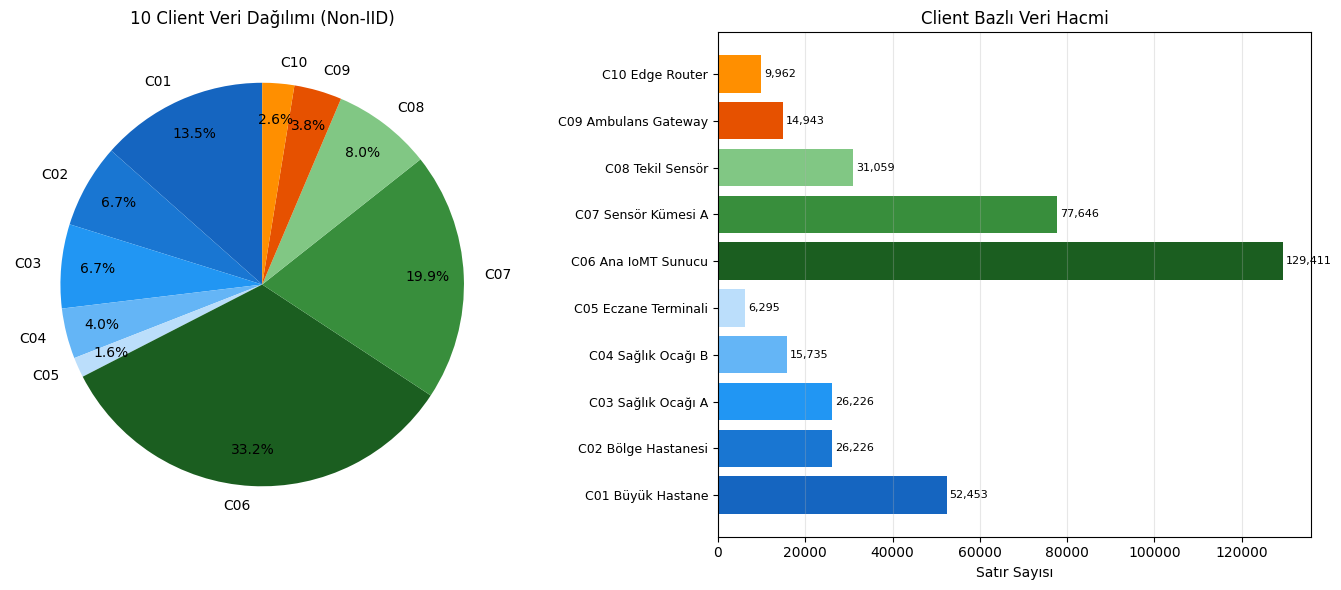


⚡ Scale → PCA → Sequence pipeline uygulanıyor...
   -> C01_Hastane   : seq shape = (52433, 20, 20) | RAM = 83.9 MB
   -> C02_BolgeH    : seq shape = (26206, 20, 20) | RAM = 41.9 MB
   -> C03_SaglikA   : seq shape = (26206, 20, 20) | RAM = 41.9 MB
   -> C04_SaglikB   : seq shape = (15715, 20, 20) | RAM = 25.1 MB
   -> C05_Eczane    : seq shape = (6275, 20, 20) | RAM = 10.0 MB
   -> C06_IoMT      : seq shape = (129391, 20, 20) | RAM = 207.0 MB
   -> C07_SensorA   : seq shape = (77626, 20, 20) | RAM = 124.2 MB
   -> C08_Sensor    : seq shape = (31039, 20, 20) | RAM = 49.7 MB
   -> C09_Ambulans  : seq shape = (14923, 20, 20) | RAM = 23.9 MB
   -> C10_Edge      : seq shape = (9942, 20, 20) | RAM = 15.9 MB

✂️  Kronolojik Train/Val bölmesi (%80/%20)...
⚡ tf.data pipeline kuruluyor (batch=512)...
   -> C01_Hastane   : train=  41,946 | val=  10,487
   -> C02_BolgeH    : train=  20,964 | val=   5,242
   -> C03_SaglikA   : train=  20,964 | val=   5,242
   -> C04_SaglikB   : train=  12,572 | val

In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 3: 10 CLIENT BAZLI VERİ BÖLME (NON-IID) VE tf.data
# =============================================================================
# 10 Client Non-IID Dağılımı (Quantity Skew + Feature Skew):
#
#   WiFi Grubu  (5 client — "hastane grubu"):
#     C1 Büyük Hastane     : WiFi %40 (en çok veri)
#     C2 Bölge Hastanesi   : WiFi %20
#     C3 Sağlık Ocağı A    : WiFi %20
#     C4 Sağlık Ocağı B    : WiFi %12
#     C5 Eczane Terminali  : WiFi %8  (en az WiFi)
#
#   MQTT Grubu  (3 client — "IoMT grubu"):
#     C6 Ana IoMT Sunucu   : MQTT %50 (en çok veri)
#     C7 Sensör Kümesi A   : MQTT %30
#     C8 Tekil Sensör      : MQTT %20
#
#   Karma Grup  (2 client — "mobil/edge grubu"):
#     C9  Ambulans Gateway : WiFi kalan + MQTT kalan (50/50)
#     C10 Edge Router      : WiFi kalan + MQTT kalan (50/50, daha az)
# =============================================================================

import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

print("=" * 65)
print("   10-CLIENT HİBRİT VERİ DAĞILIMI VE PİPELİNE")
print("=" * 65)

# 1. PROTOKOL AYIRMA
print("\n📂 Client dosya listesi oluşturuluyor...")
wifi_files  = []
mqtt_files  = []

for f in all_benign_files:
    fname = os.path.basename(f).lower()
    if 'mqtt' in fname:
        mqtt_files.append(f)
    else:
        wifi_files.append(f)

if len(mqtt_files) < 2:
    print("   ⚠️ İsimden MQTT ayrımı yapılamadı → dosyalar rastgele bölünüyor...")
    mid = len(all_benign_files) // 2
    wifi_files  = all_benign_files[:mid]
    mqtt_files  = all_benign_files[mid:]

print(f"   -> Toplam WiFi dosya sayısı : {len(wifi_files)}")
print(f"   -> Toplam MQTT dosya sayısı : {len(mqtt_files)}")

# 2. ANA DATAFRAME'LERİN OLUŞTURULMASI
print("\n⏳ Ana protokol havuzları oluşturuluyor...")

def load_client_df(file_list, desc_name):
    dfs = []
    for f in file_list:
        try:
            df = pd.read_csv(f)
            df = df.select_dtypes(include=[np.number]).astype('float32')
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            df.dropna(inplace=True)
            for col in set(FEATURE_COLUMNS) - set(df.columns):
                df[col] = 0.0
            df = df[FEATURE_COLUMNS]
            dfs.append(df)
        except Exception as e:
            pass
    result = pd.concat(dfs, ignore_index=True)
    print(f"   -> {desc_name} Toplam Boyutu: {result.shape}")
    return result

df_wifi_all = load_client_df(wifi_files, "Tüm WiFi Havuzu")
df_mqtt_all = load_client_df(mqtt_files, "Tüm MQTT Havuzu")

# 3. 10 CLIENT NON-IID BÖLÜNME
print("\n🔪 10 Client için veri parçalanıyor...")

# WiFi → 5 parça: %40, %20, %20, %12, %8
w_total = len(df_wifi_all)
w_c1_end = int(w_total * 0.40)
w_c2_end = w_c1_end + int(w_total * 0.20)
w_c3_end = w_c2_end + int(w_total * 0.20)
w_c4_end = w_c3_end + int(w_total * 0.12)
# C5: kalan (≈8%) → C5'e; ama C9/C10 için de bir miktar ayrılması gerekiyor
# WiFi leftover ikiye bölünür: %60 C5, %40 Karma havuzu için
wifi_c5_raw = df_wifi_all.iloc[w_c4_end:]
w_c5_cut = int(len(wifi_c5_raw) * 0.60)
df_c1 = df_wifi_all.iloc[:w_c1_end]
df_c2 = df_wifi_all.iloc[w_c1_end:w_c2_end]
df_c3 = df_wifi_all.iloc[w_c2_end:w_c3_end]
df_c4 = df_wifi_all.iloc[w_c3_end:w_c4_end]
df_c5 = wifi_c5_raw.iloc[:w_c5_cut]
wifi_leftover = wifi_c5_raw.iloc[w_c5_cut:]

# MQTT → 3 parça: %50, %30, %20
m_total = len(df_mqtt_all)
m_c6_end = int(m_total * 0.50)
m_c7_end = m_c6_end + int(m_total * 0.30)
# MQTT leftover → %60 C8, %40 Karma havuzu
mqtt_c8_raw = df_mqtt_all.iloc[m_c7_end:]
m_c8_cut = int(len(mqtt_c8_raw) * 0.60)
df_c6 = df_mqtt_all.iloc[:m_c6_end]
df_c7 = df_mqtt_all.iloc[m_c6_end:m_c7_end]
df_c8 = mqtt_c8_raw.iloc[:m_c8_cut]
mqtt_leftover = mqtt_c8_raw.iloc[m_c8_cut:]

# Karma → C9 ve C10: leftover'ları 60/40 oranında paylaşır
karma_pool = pd.concat([wifi_leftover, mqtt_leftover], ignore_index=True)
karma_cut  = int(len(karma_pool) * 0.60)
df_c9  = karma_pool.iloc[:karma_cut]
df_c10 = karma_pool.iloc[karma_cut:]

client_dfs = [
    (df_c1,  "C01 Büyük Hastane (WiFi %40)"),
    (df_c2,  "C02 Bölge Hastanesi (WiFi %20)"),
    (df_c3,  "C03 Sağlık Ocağı A (WiFi %20)"),
    (df_c4,  "C04 Sağlık Ocağı B (WiFi %12)"),
    (df_c5,  "C05 Eczane Terminali (WiFi %8)"),
    (df_c6,  "C06 Ana IoMT Sunucu (MQTT %50)"),
    (df_c7,  "C07 Sensör Kümesi A (MQTT %30)"),
    (df_c8,  "C08 Tekil Sensör (MQTT %20)"),
    (df_c9,  "C09 Ambulans Gateway (Karma %60)"),
    (df_c10, "C10 Edge Router (Karma %40)"),
]

print(f"\n{'Client':<38} {'Satır':>10} {'Kolon':>7}")
print("-" * 57)
for df, name in client_dfs:
    print(f"   {name:<36}: {df.shape[0]:>8,}  {df.shape[1]:>6}")

del df_wifi_all, df_mqtt_all, karma_pool
gc.collect()

# 4. VERİ DAĞILIMI PASTA GRAFİĞİ
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sizes  = [len(df) for df, _ in client_dfs]
labels = [name.split(" ")[0] for _, name in client_dfs]
colors_pie = [
    '#1565C0','#1976D2','#2196F3','#64B5F6','#BBDEFB',  # WiFi: koyu→açık mavi
    '#1B5E20','#388E3C','#81C784',                        # MQTT: koyu→açık yeşil
    '#E65100','#FF8F00'                                   # Karma: turuncu
]
axes[0].pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%',
            startangle=90, pctdistance=0.82)
axes[0].set_title('10 Client Veri Dağılımı (Non-IID)', fontsize=12)

bar_labels = [name for _, name in client_dfs]
axes[1].barh(range(len(sizes)), sizes, color=colors_pie)
axes[1].set_yticks(range(len(sizes)))
axes[1].set_yticklabels([n.split("(")[0].strip() for _, n in client_dfs], fontsize=9)
axes[1].set_xlabel('Satır Sayısı')
axes[1].set_title('Client Bazlı Veri Hacmi', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(sizes):
    axes[1].text(v + max(sizes)*0.005, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('client_veri_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. SEQUENCE OLUŞTURMA
def create_sequences_fast(data, time_steps):
    n_samples  = data.shape[0] - time_steps
    shape   = (n_samples, time_steps, data.shape[1])
    strides = (data.strides[0], data.strides[0], data.strides[1])
    seq = np.lib.stride_tricks.as_strided(data, shape=shape, strides=strides)
    return np.array(seq, dtype=np.float32)

print(f"\n⚡ Scale → PCA → Sequence pipeline uygulanıyor...")

def apply_pipeline(df, client_name):
    scaled    = scaler.transform(df).astype(np.float32)
    pca_trans = pca.transform(scaled).astype(np.float32)
    sequences = create_sequences_fast(pca_trans, TIME_STEPS)
    print(f"   -> {client_name:<14}: seq shape = {sequences.shape} | RAM = {sequences.nbytes / 1e6:.1f} MB")
    return sequences

client_sequences = []
client_short_names = [
    "C01_Hastane", "C02_BolgeH", "C03_SaglikA", "C04_SaglikB", "C05_Eczane",
    "C06_IoMT",    "C07_SensorA", "C08_Sensor",  "C09_Ambulans", "C10_Edge"
]

for (df, _), cname in zip(client_dfs, client_short_names):
    client_sequences.append(apply_pipeline(df, cname))

del df_c1,df_c2,df_c3,df_c4,df_c5,df_c6,df_c7,df_c8,df_c9,df_c10
if 'df_full' in globals():
    del df_full
gc.collect()

# 6. TRAIN / VAL SPLIT VE TF.DATA
print(f"\n✂️  Kronolojik Train/Val bölmesi (%80/%20)...")
print(f"⚡ tf.data pipeline kuruluyor (batch={BATCH_SIZE})...")

AUTOTUNE = tf.data.AUTOTUNE

def split_and_make_ds(X, name):
    split_idx = int(len(X) * (1 - TEST_SIZE))
    X_tr  = X[:split_idx]
    X_val = X[split_idx:]
    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_tr, X_tr))
        .cache()
        .shuffle(buffer_size=15000, seed=SEED)
        .batch(BATCH_SIZE, drop_remainder=True)
        .prefetch(AUTOTUNE)
    )
    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, X_val))
        .cache()
        .batch(BATCH_SIZE, drop_remainder=False)
        .prefetch(AUTOTUNE)
    )
    print(f"   -> {name:<14}: train={X_tr.shape[0]:>8,} | val={X_val.shape[0]:>8,}")
    return train_ds, val_ds, len(X_tr), len(X_val)

CLIENT_DATASETS = []
for seq_data, cname in zip(client_sequences, client_short_names):
    t_ds, v_ds, n_tr, n_v = split_and_make_ds(seq_data, cname)
    CLIENT_DATASETS.append({
        "name": cname,
        "train": t_ds,
        "val":   v_ds,
        "n_train": n_tr,
        "n_val":   n_v
    })

del client_sequences
gc.collect()

print("\n" + "=" * 65)
print("   HÜCRE 3 TAMAMLANDI — HÜCRE 4'E GEÇEBİLİRSİNİZ")
print("=" * 65)

In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 4: MODEL MİMARİSİ (BİREBİR KORUNDU, NaN-SAFE)
# =============================================================================
# MİMARİ — ORİJİNAL İLE AYNI:
#   ENCODER:
#     Conv1D(64)                    → lokal örüntü çıkarımı
#     BiLSTM(128)                   → zamansal bağımlılık (iki yön)
#     TransformerBlock(256, 4head)  → global dikkat mekanizması
#     LSTM(64) + LayerNorm          → bottleneck
#     TransformerBlock(64,  4head)  → bottleneck dikkat
#   DECODER:
#     LSTM(128)
#     TransformerBlock(128, 4head)
#     LSTM(256)
#     TimeDistributed Dense(PCA_COMPONENTS) → rekonstrüksiyon
#
# LOSS: 0.6*MAE + 0.4*MSE (float32 cast ile NaN-safe)
# OPT : Adam(lr=LEARNING_RATE, clipvalue=0.5, epsilon=1e-7)
# =============================================================================

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, Add, TimeDistributed, Conv1D,
    Bidirectional, Lambda
)
from tensorflow.keras.optimizers import Adam
import gc

print("=" * 65)
print("   MHA-LSTM MODEL MİMARİSİ KURULUYOR (NaN-SAFE, ORİJİNAL)")
print("=" * 65)

tf.keras.backend.clear_session()
gc.collect()

# NaN-SAFE COMBINED LOSS
def combined_reconstruction_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    return 0.6 * mae + 0.4 * mse

# TRANSFORMER ENCODER BLOĞU (orijinal ile birebir)
def transformer_encoder_block(x, embed_dim, num_heads, ff_dim,
                               dropout_rate, name_prefix=""):
    attn_input  = LayerNormalization(epsilon=1e-5, name=f"{name_prefix}_ln1")(x)
    attn_output = MultiHeadAttention(
                      num_heads=num_heads,
                      key_dim=embed_dim // num_heads,
                      dropout=dropout_rate,
                      name=f"{name_prefix}_mha"
                  )(attn_input, attn_input)
    x = Add(name=f"{name_prefix}_add1")([x, attn_output])
    ff_input  = LayerNormalization(epsilon=1e-5, name=f"{name_prefix}_ln2")(x)
    ff_output = Dense(ff_dim, activation='relu', name=f"{name_prefix}_ff1")(ff_input)
    ff_output = Dropout(dropout_rate, name=f"{name_prefix}_drop")(ff_output)
    ff_output = Dense(embed_dim, name=f"{name_prefix}_ff2")(ff_output)
    x = Add(name=f"{name_prefix}_add2")([x, ff_output])
    return x

# MODEL MİMARİSİ (orijinal ile birebir)
def build_model(time_steps, pca_components):
    inputs = Input(shape=(time_steps, pca_components), dtype='float32', name='input')

    # ENCODER
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu',
               name='conv_local')(inputs)

    x = Bidirectional(
            LSTM(128, return_sequences=True, activation='tanh',
                 recurrent_dropout=0.0,
                 kernel_initializer='glorot_uniform',
                 recurrent_initializer='orthogonal'),
            name='bilstm_encoder'
        )(x)
    x = Dropout(0.15, name='drop_enc_1')(x)

    x = transformer_encoder_block(
            x, embed_dim=256, num_heads=4, ff_dim=512,
            dropout_rate=0.1, name_prefix="enc_transformer"
        )

    encoder_out = LSTM(64, return_sequences=True, activation='tanh',
                       kernel_initializer='glorot_uniform',
                       recurrent_initializer='orthogonal',
                       name='bottleneck')(x)
    encoder_out = LayerNormalization(epsilon=1e-5, name='bottleneck_ln')(encoder_out)

    x = transformer_encoder_block(
            encoder_out, embed_dim=64, num_heads=4, ff_dim=128,
            dropout_rate=0.1, name_prefix="bottleneck_transformer"
        )

    # DECODER
    x = LSTM(128, return_sequences=True, activation='tanh',
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal',
             name='lstm_dec_1')(x)
    x = Dropout(0.15, name='drop_dec_1')(x)

    x = transformer_encoder_block(
            x, embed_dim=128, num_heads=4, ff_dim=256,
            dropout_rate=0.1, name_prefix="dec_transformer"
        )

    x = LSTM(256, return_sequences=True, activation='tanh',
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal',
             name='lstm_dec_2')(x)
    x = Dropout(0.1, name='drop_dec_2')(x)

    # OUTPUT
    x       = TimeDistributed(Dense(pca_components), name='output_dense')(x)
    outputs = Lambda(lambda t: tf.cast(t, tf.float32), name='output_cast')(x)

    model = Model(inputs=inputs, outputs=outputs,
                  name='Federe_MHA_LSTM_Autoencoder_10Client')

    optimizer = Adam(learning_rate=LEARNING_RATE, clipvalue=0.5, epsilon=1e-7)
    model.compile(optimizer=optimizer, loss=combined_reconstruction_loss)
    return model

global_model = build_model(TIME_STEPS, PCA_COMPONENTS)
global_model.summary()

total_params = global_model.count_params()
print(f"\n📊 Model İstatistikleri:")
print(f"   -> Toplam parametre       : {total_params:,}")
print(f"   -> Tahmini model boyutu   : {total_params * 4 / 1e6:.1f} MB (float32)")
print(f"   -> Input shape            : ({TIME_STEPS}, {PCA_COMPONENTS})")
print(f"   -> Loss                   : Combined (60% MAE + 40% MSE)")
print(f"   -> Optimizer              : Adam (lr={LEARNING_RATE}, clipvalue=0.5)")

global_weights = global_model.get_weights()
print(f"\n✅ global_weights hazır — {len(global_weights)} katman ağırlığı")

print("\n" + "=" * 65)
print("   HÜCRE 4 TAMAMLANDI — HÜCRE 5'E GEÇEBİLİRSİNİZ")
print("=" * 65)

   MHA-LSTM MODEL MİMARİSİ KURULUYOR (NaN-SAFE, ORİJİNAL)


Model: "Federe_MHA_LSTM_Autoencoder_10Client"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 20, 20)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_local (Conv1D) │ (None, 20, 64)    │      3,904 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_encoder      │ (None, 20, 256)   │    197,632 │ conv_local[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_enc_1          │ (None, 20, 256)   │          0 │ bilstm_encoder[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ln1 │ (None, 20, 256)   │        512 │ drop_enc_1[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_mha │ (None, 20, 256)   │    263,168 │ enc_transformer_… │
│ (MultiHeadAttentio… │                   │            │ enc_transformer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ad… │ (None, 20, 256)   │          0 │ drop_enc_1[0][0], │
│ (Add)               │                   │            │ enc_transformer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ln2 │ (None, 20, 256)   │        512 │ enc_transformer_… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ff1 │ (None, 20, 512)   │    131,584 │ enc_transformer_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_dr… │ (None, 20, 512)   │          0 │ enc_transformer_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ff2 │ (None, 20, 256)   │    131,328 │ enc_transformer_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ad… │ (None, 20, 256)   │          0 │ enc_transformer_… │
│ (Add)               │                   │            │ enc_transformer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck (LSTM)   │ (None, 20, 64)    │     82,176 │ enc_transformer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_ln       │ (None, 20, 64)    │        128 │ bottleneck[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_transfo… │ (None, 20, 64)    │        128 │ bottleneck_ln[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_transfo… │ (None, 20, 64)    │     16,640 │ bottleneck_trans… │
│ (MultiHeadAttentio… │                   │            │ bottleneck_trans… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_transfo… │ (None, 20, 64)    │          0 │ bottleneck_ln[0]… │
│ (Add)               │                   │            │ bottleneck_trans… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_transfo… │ (None, 20, 64)    │        128 │ bottleneck_trans

 Total params: 1,475,092 (5.63 MB)

 Trainable params: 1,475,092 (5.63 MB)

 Non-trainable params: 0 (0.00 B)


📊 Model İstatistikleri:
   -> Toplam parametre       : 1,475,092
   -> Tahmini model boyutu   : 5.9 MB (float32)
   -> Input shape            : (20, 20)
   -> Loss                   : Combined (60% MAE + 40% MSE)
   -> Optimizer              : Adam (lr=0.001, clipvalue=0.5)

✅ global_weights hazır — 69 katman ağırlığı

   HÜCRE 4 TAMAMLANDI — HÜCRE 5'E GEÇEBİLİRSİNİZ


   FEDERE EĞİTİM BAŞLIYOR (10 CLIENT — COSINE DECAY — 50 ROUND)
   -> Rounds        : 50
   -> Local Epochs  : 8
   -> Batch Size    : 512
   -> Clients       : 10
   -> LR başlangıç  : 0.001  → cosine → 1e-6
   -> Early Stop    : patience=10
   -> Aggregation   : Weighted FedAvg

📉 Cosine Decay LR Planı:
   Round  1: 0.001000  ████████████████████
   Round 10: 0.000922  ██████████████████
   Round 20: 0.000684  █████████████
   Round 30: 0.000376  ███████
   Round 40: 0.000116  ██
   Round 50: 0.000002  

──────────────────────────────────────────────────────────────────────
  Round   Global Val     ΔLoss         LR     Süre  Durum
──────────────────────────────────────────────────────────────────────
      [   C01_Hastane]  train=0.27960 | val=0.21530 | LR=0.001000 | 75.2s
      [    C02_BolgeH]  train=0.30925 | val=0.11327 | LR=0.001000 | 57.6s
      [   C03_SaglikA]  train=0.26710 | val=0.15327 | LR=0.001000 | 51.6s
      [   C04_SaglikB]  train=0.81307 | val=1.87514 | LR=0.001000 

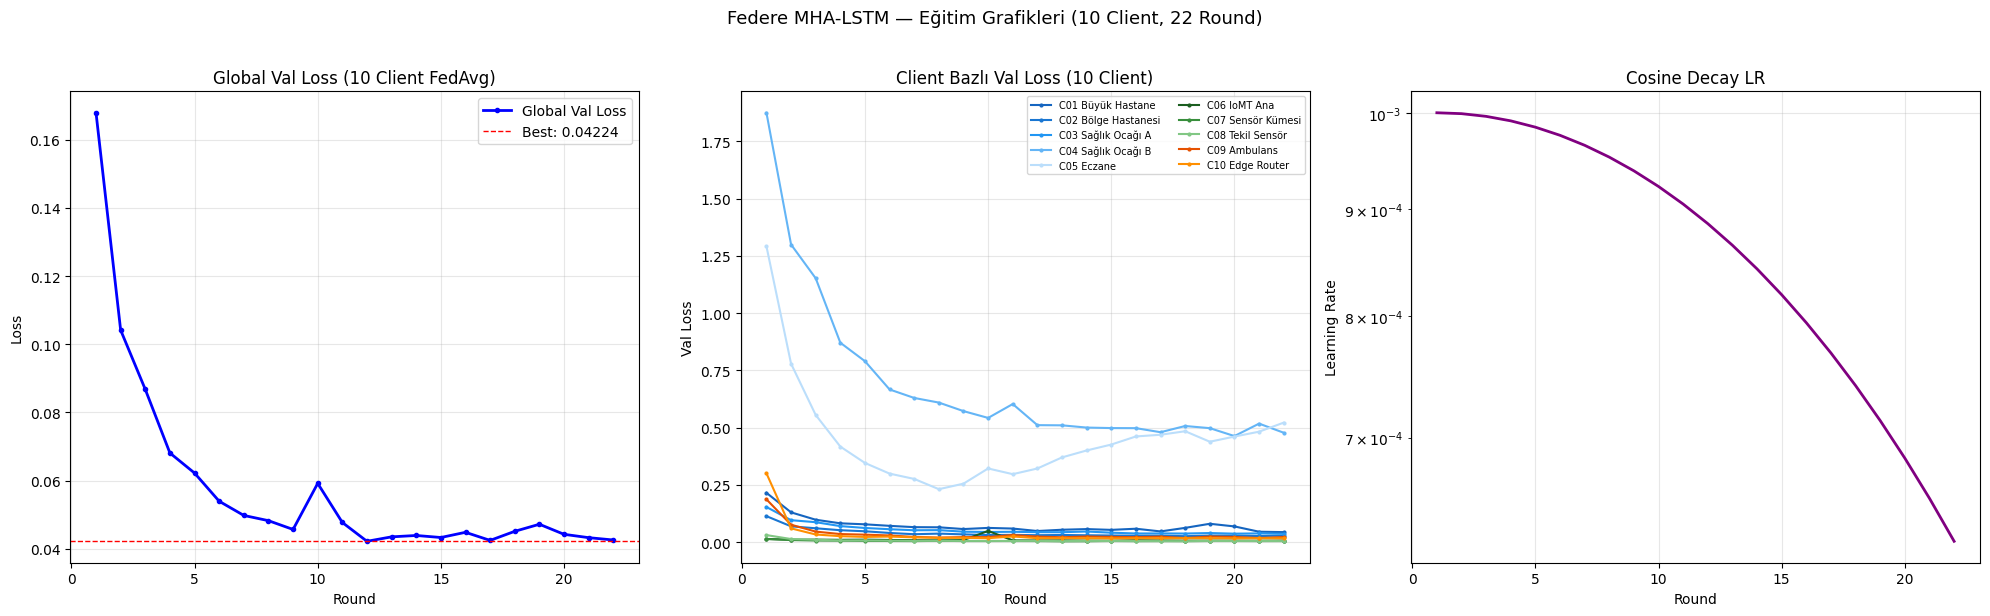


📊 CLIENT BAZLI İYİLEŞME TABLOSU (10 CLIENT NON-IID)
────────────────────────────────────────────────────────────────────
  Client                 |    Round 1 |  Son Round |   İyileşme
────────────────────────────────────────────────────────────────────
  C01 Büyük Hastane      |    0.21530 |    0.04357 | %     79.8
  C02 Bölge Hastanesi    |    0.11327 |    0.02875 | %     74.6
  C03 Sağlık Ocağı A     |    0.15327 |    0.03623 | %     76.4
  C04 Sağlık Ocağı B     |    1.87514 |    0.47762 | %     74.5
  C05 Eczane             |    1.29189 |    0.52177 | %     59.6
  C06 IoMT Ana           |    0.01389 |    0.00658 | %     52.6
  C07 Sensör Kümesi      |    0.01361 |    0.00472 | %     65.3
  C08 Tekil Sensör       |    0.03061 |    0.00428 | %     86.0
  C09 Ambulans           |    0.18666 |    0.02219 | %     88.1
  C10 Edge Router        |    0.30054 |    0.01644 | %     94.5

✅ Hücre 5 tamamlandı — Hücre 6'ya geçebilirsiniz.


In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 5: FEDERE EĞİTİM DÖNGÜSÜ (10 CLIENT)
# =============================================================================
# Yöntem: Weighted FedAvg + Cosine Decay LR + Early Stopping (patience=10)
# Orijinalden tek fark: client_val listesi 10 elemanlı,
# grafik/tablo renk paleti ve etiketler 10 client'a uyarlandı.
# =============================================================================

import tensorflow as tf
import numpy as np
import time
import math
import matplotlib.pyplot as plt
import gc

print("=" * 65)
print("   FEDERE EĞİTİM BAŞLIYOR (10 CLIENT — COSINE DECAY — 50 ROUND)")
print("=" * 65)
print(f"   -> Rounds        : {ROUNDS}")
print(f"   -> Local Epochs  : {LOCAL_EPOCHS}")
print(f"   -> Batch Size    : {BATCH_SIZE}")
print(f"   -> Clients       : {NUM_CLIENTS}")
print(f"   -> LR başlangıç  : {LEARNING_RATE}  → cosine → 1e-6")
print(f"   -> Early Stop    : patience=10")
print(f"   -> Aggregation   : Weighted FedAvg")

# 1. COSINE DECAY
def cosine_lr(round_idx, total_rounds, lr_max=LEARNING_RATE, lr_min=1e-6):
    decay = 0.5 * (1.0 + math.cos(math.pi * round_idx / total_rounds))
    return lr_min + (lr_max - lr_min) * decay

print("\n📉 Cosine Decay LR Planı:")
for r in [0, 9, 19, 29, 39, 49]:
    lr_val = cosine_lr(r, ROUNDS)
    bar = "█" * int(lr_val / LEARNING_RATE * 20)
    print(f"   Round {r+1:>2}: {lr_val:.6f}  {bar}")

# 2. AĞIRLIKLI FedAvg
def weighted_fed_avg(weights_list, n_samples_list):
    total     = sum(n_samples_list)
    fractions = [n / total for n in n_samples_list]
    new_weights = []
    for layer_weights in zip(*weights_list):
        averaged = np.sum(
            [frac * w for frac, w in zip(fractions, layer_weights)],
            axis=0
        )
        new_weights.append(averaged)
    return new_weights


# 3. TEK CLIENT EĞİTİMİ
def train_one_client(global_weights, client_info, local_epochs, current_lr):
    name     = client_info["name"]
    train_ds = client_info["train"]
    val_ds   = client_info["val"]

    local_model = build_model(TIME_STEPS, PCA_COMPONENTS)
    local_model.set_weights(global_weights)
    local_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=current_lr, clipvalue=0.5, epsilon=1e-7
        ),
        loss=combined_reconstruction_loss
    )

    t0 = time.time()
    history = local_model.fit(
        train_ds, validation_data=val_ds,
        epochs=local_epochs, verbose=0
    )
    elapsed = time.time() - t0

    # GÜVENLİK KONTROLÜ: Eğitim gerçekleşti mi ve 'loss' üretildi mi?
    if 'loss' in history.history and len(history.history['loss']) > 0:
        train_loss = history.history['loss'][-1]
        val_loss   = history.history['val_loss'][-1]

        print(f"      [{name:>14}]  "
              f"train={train_loss:.5f} | val={val_loss:.5f} | "
              f"LR={current_lr:.6f} | {elapsed:.1f}s")
    else:
        # Veri yetersizliğinden eğitim gerçekleşmediyse sistemi çökertme
        print(f"      [{name:>14}]  UYARI: Veri yetersiz, eğitim atlandı!")
        train_loss = 999.0
        val_loss   = 999.0

    new_weights = local_model.get_weights()
    del local_model
    tf.keras.backend.clear_session()
    gc.collect()

    return new_weights, train_loss, val_loss

# 4. ANA FEDERE DÖNGÜ (10 CLIENT)
history_rounds = {
    'train_loss': [],
    'val_loss':   [],
    'client_val': [[] for _ in range(NUM_CLIENTS)],  # 10 boş liste
    'lr':         []
}

global_weights   = global_model.get_weights()
best_val_loss    = float('inf')
best_weights     = None
patience_counter = 0
PATIENCE         = 10
total_start      = time.time()

print("\n" + "─" * 70)
print(f"  {'Round':>5}  {'Global Val':>11}  {'ΔLoss':>8}  {'LR':>9}  {'Süre':>7}  Durum")
print("─" * 70)

for round_idx in range(ROUNDS):
    round_start = time.time()
    current_lr  = cosine_lr(round_idx, ROUNDS)

    client_weights   = []
    client_n         = []
    round_val_losses = []

    for c_idx, client_info in enumerate(CLIENT_DATASETS):
        new_w, t_loss, v_loss = train_one_client(
            global_weights, client_info, LOCAL_EPOCHS, current_lr
        )
        client_weights.append(new_w)
        client_n.append(client_info["n_train"])
        round_val_losses.append(v_loss)
        history_rounds['client_val'][c_idx].append(v_loss)

    # Weighted FedAvg
    global_weights = weighted_fed_avg(client_weights, client_n)
    global_model.set_weights(global_weights)

    total_n    = sum(client_n)
    global_val = sum(v * n / total_n for v, n in zip(round_val_losses, client_n))

    history_rounds['train_loss'].append(
        sum(history_rounds['client_val'][i][-1] * client_n[i] / total_n
            for i in range(NUM_CLIENTS))
    )
    history_rounds['val_loss'].append(global_val)
    history_rounds['lr'].append(current_lr)

    delta = best_val_loss - global_val
    if global_val < best_val_loss - 1e-5:
        best_val_loss    = global_val
        best_weights     = [w.copy() for w in global_weights]
        patience_counter = 0
        status = "✅ best"
    else:
        patience_counter += 1
        status = f"⏳ {patience_counter}/{PATIENCE}"

    round_time = time.time() - round_start
    print(f"  {round_idx+1:>5}  {global_val:>11.5f}  "
          f"{delta:>+8.5f}  {current_lr:>9.6f}  "
          f"{round_time:>5.1f}s  {status}")

    if patience_counter >= PATIENCE:
        print(f"\n⛔ Early stopping — {PATIENCE} round iyileşme yok.")
        print(f"   En iyi val_loss: {best_val_loss:.5f}  (Round {round_idx+1 - PATIENCE})")
        break

print("\n" + "─" * 70)
global_model.set_weights(best_weights)
print(f"✅ Best weights yüklendi  → val_loss: {best_val_loss:.5f}")

# 5. EĞİTİM GRAFİKLERİ (10 CLIENT)
colors_10 = [
    '#1565C0','#1976D2','#2196F3','#64B5F6','#BBDEFB',  # WiFi (5 ton mavi)
    '#1B5E20','#388E3C','#81C784',                        # MQTT (3 ton yeşil)
    '#E65100','#FF8F00'                                   # Karma (2 ton turuncu)
]
labels_10 = [
    'C01 Büyük Hastane', 'C02 Bölge Hastanesi', 'C03 Sağlık Ocağı A',
    'C04 Sağlık Ocağı B', 'C05 Eczane',
    'C06 IoMT Ana', 'C07 Sensör Kümesi', 'C08 Tekil Sensör',
    'C09 Ambulans', 'C10 Edge Router'
]

actual_rounds = len(history_rounds['val_loss'])
rounds_x = range(1, actual_rounds + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Global Val Loss
axes[0].plot(rounds_x, history_rounds['val_loss'], 'b-o', markersize=3, linewidth=2, label='Global Val Loss')
axes[0].axhline(best_val_loss, color='red', linestyle='--', linewidth=1,
                label=f'Best: {best_val_loss:.5f}')
axes[0].set_title('Global Val Loss (10 Client FedAvg)')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Client Bazlı Val Loss
for i in range(NUM_CLIENTS):
    axes[1].plot(rounds_x, history_rounds['client_val'][i],
                 color=colors_10[i], linewidth=1.5, marker='o',
                 markersize=2, label=labels_10[i])
axes[1].set_title('Client Bazlı Val Loss (10 Client)')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Val Loss')
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

# Panel 3: LR Cosine Decay
axes[2].plot(rounds_x, history_rounds['lr'], 'purple', linewidth=2)
axes[2].set_title('Cosine Decay LR')
axes[2].set_xlabel('Round')
axes[2].set_ylabel('Learning Rate')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Federe MHA-LSTM — Eğitim Grafikleri (10 Client, {actual_rounds} Round)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('faz1_egitim_grafikleri_10client.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. CLIENT İYİLEŞME TABLOSU
print("\n📊 CLIENT BAZLI İYİLEŞME TABLOSU (10 CLIENT NON-IID)")
print("─" * 68)
print(f"  {'Client':<22} | {'Round 1':>10} | {'Son Round':>10} | {'İyileşme':>10}")
print("─" * 68)
for i, name in enumerate(labels_10):
    v_start = history_rounds['client_val'][i][0]
    v_end   = history_rounds['client_val'][i][-1]
    improv  = (v_start - v_end) / v_start * 100 if v_start > 0 else 0
    print(f"  {name:<22} | {v_start:>10.5f} | {v_end:>10.5f} | %{improv:>9.1f}")

print("\n✅ Hücre 5 tamamlandı — Hücre 6'ya geçebilirsiniz.")

   ADAPTİF THRESHOLD VE TAM DEĞERLENDİRME (10 CLIENT)

🔍 Normal val seti reconstruction error (10 client birleşik)...
   -> 10 Client val setleri skorlanıyor...
      [   C01_Hastane]:   10,487 örnek | mean_mae=0.19804
      [    C02_BolgeH]:    5,242 örnek | mean_mae=0.16670
      [   C03_SaglikA]:    5,242 örnek | mean_mae=0.21515
      [   C04_SaglikB]:    3,143 örnek | mean_mae=0.39995
      [    C05_Eczane]:    1,255 örnek | mean_mae=0.32841
      [      C06_IoMT]:   25,879 örnek | mean_mae=0.03992
      [   C07_SensorA]:   15,526 örnek | mean_mae=0.03981
      [    C08_Sensor]:    6,208 örnek | mean_mae=0.04032
      [  C09_Ambulans]:    2,985 örnek | mean_mae=0.13046
      [      C10_Edge]:    1,989 örnek | mean_mae=0.15708

   Normal Val MAE İstatistikleri (toplam 77,956 örnek):
   -> Min   : 0.03125
   -> Max   : 1.58577
   -> Mean  : 0.10712
   -> Std   : 0.12404
   -> p95   : 0.30499
   -> p99   : 0.57806
   -> p99.9 : 1.30522

📂 Saldırı (Attack) dosyaları taranıyor...
   ->

   Normal Test: 100%|██████████| 9/9 [02:35<00:00, 17.27s/it]



⚡ Saldırı dosyaları skorlanıyor...


   Saldırı: 100%|██████████| 72/72 [25:01<00:00, 20.86s/it]



📊 Test Seti Özeti:
   -> Normal  örnek : 213,997
   -> Saldırı örnek : 8,773,573
   -> Toplam        : 8,987,570

🎯 F1-optimize adaptif threshold...
   -> Optimal Threshold : 0.04716
   -> Beklenen F1 Score : 0.9925
   -> Threshold kaydedildi.

   SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

      Normal     0.6389    0.9000    0.7473    213997
     Saldırı     0.9975    0.9876    0.9925   8773573

    accuracy                         0.9855   8987570
   macro avg     0.8182    0.9438    0.8699   8987570
weighted avg     0.9890    0.9855    0.9867   8987570


📌 PR-Optimize (min recall≥%97): threshold=0.20755 | precision=%99.94


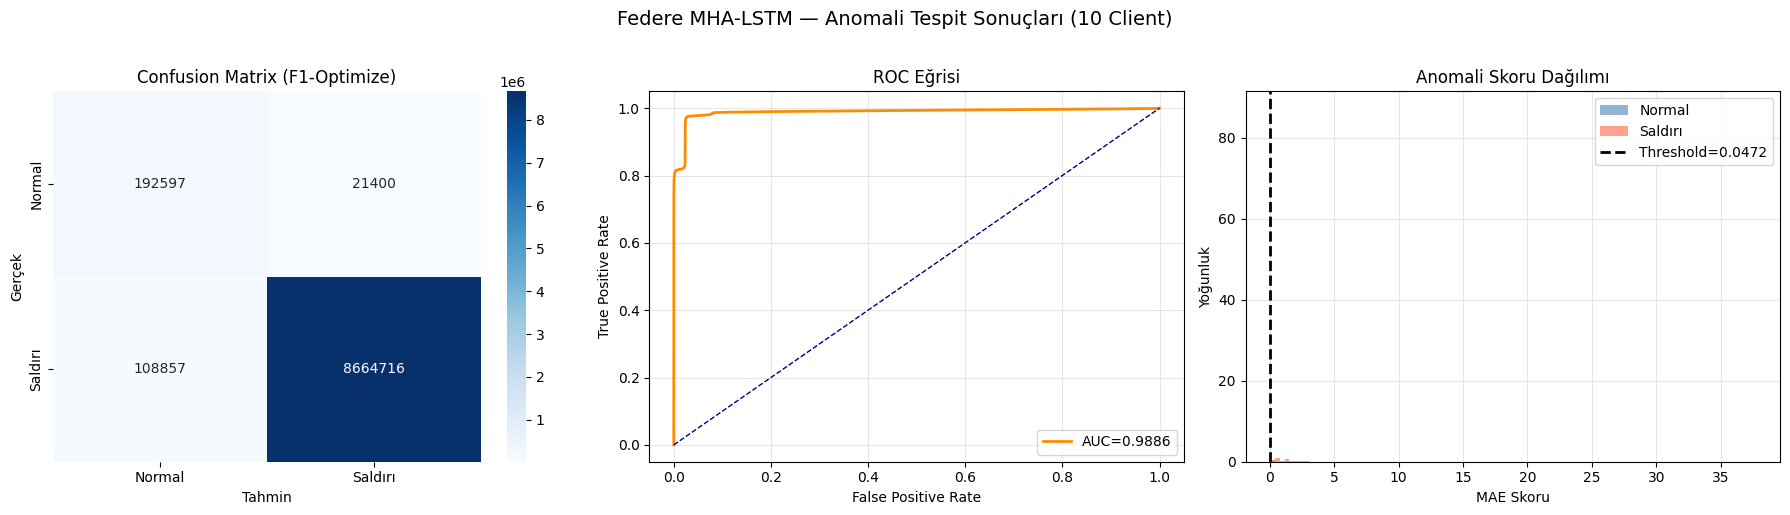


✅ ROC AUC : 0.9886

   HÜCRE 6 TAMAMLANDI — HÜCRE 7'YE GEÇEBİLİRSİNİZ


In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 6: ADAPTİF THRESHOLD VE TAM DEĞERLENDİRME
# =============================================================================
# 10 Client uyumlu — orijinal pipeline korundu:
#   1. 10 client val seti → reconstruction error baseline
#   2. Attack dosyaları → pipeline → skorlama
#   3. F1-optimize adaptif threshold
#   4. Precision-Recall dengesi
#   5. Confusion matrix + ROC + skor dağılımı grafikleri
# =============================================================================

import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, f1_score, precision_recall_curve
)
import tensorflow as tf
import joblib
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

print("=" * 65)
print("   ADAPTİF THRESHOLD VE TAM DEĞERLENDİRME (10 CLIENT)")
print("=" * 65)

# 1. NORMAL VAL SETİ — 10 CLIENT BASELINE
print("\n🔍 Normal val seti reconstruction error (10 client birleşik)...")

def score_dataset(dataset, model):
    all_preds = []
    all_true  = []
    for batch_x, _ in dataset:
        preds = model(batch_x, training=False)
        all_preds.append(preds.numpy())
        all_true.append(batch_x.numpy())
    X_true = np.concatenate(all_true,  axis=0).astype(np.float32)
    X_pred = np.concatenate(all_preds, axis=0).astype(np.float32)
    mae = np.mean(np.abs(X_true - X_pred), axis=(1, 2))
    return mae

print("   -> 10 Client val setleri skorlanıyor...")
val_maes = []
for client_info in CLIENT_DATASETS:
    mae_skor = score_dataset(client_info["val"], global_model)
    val_maes.append(mae_skor)
    print(f"      [{client_info['name']:>14}]: {len(mae_skor):>8,} örnek | "
          f"mean_mae={np.mean(mae_skor):.5f}")

val_mae_normal = np.concatenate(val_maes)

print(f"\n   Normal Val MAE İstatistikleri (toplam {len(val_mae_normal):,} örnek):")
print(f"   -> Min   : {val_mae_normal.min():.5f}")
print(f"   -> Max   : {val_mae_normal.max():.5f}")
print(f"   -> Mean  : {val_mae_normal.mean():.5f}")
print(f"   -> Std   : {val_mae_normal.std():.5f}")
print(f"   -> p95   : {np.percentile(val_mae_normal, 95):.5f}")
print(f"   -> p99   : {np.percentile(val_mae_normal, 99):.5f}")
print(f"   -> p99.9 : {np.percentile(val_mae_normal, 99.9):.5f}")

# 2. SALDIRI DOSYALARINI TARA
print("\n📂 Saldırı (Attack) dosyaları taranıyor...")
attack_files      = []
test_benign_files = []

for root, dirs, files in os.walk(ROOT_PATH):
    for file in files:
        if file.endswith(".csv"):
            full_path = os.path.join(root, file)
            if 'attacks' in root.lower():
                attack_files.append(full_path)
            elif 'profiling' in root.lower():
                test_benign_files.append(full_path)

test_benign_files = test_benign_files[int(len(test_benign_files) * 0.8):]
print(f"   -> Saldırı dosyası     : {len(attack_files)}")
print(f"   -> Test normal dosyası : {len(test_benign_files)}")

# 3. DOSYADAN SKORLAMA
def score_files(file_list, label, desc=""):
    expected_cols = list(scaler.feature_names_in_)
    all_scores    = []
    all_labels    = []
    for f in tqdm(file_list, desc=f"   {desc}"):
        try:
            df = pd.read_csv(f).select_dtypes(include=[np.number]).astype('float32')
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            df.dropna(inplace=True)
            if len(df) <= TIME_STEPS:
                continue
            for col in set(expected_cols) - set(df.columns):
                df[col] = 0.0
            df = df[expected_cols]
            scaled    = scaler.transform(df).astype(np.float32)
            pca_trans = pca.transform(scaled).astype(np.float32)
            n_samples  = pca_trans.shape[0] - TIME_STEPS
            shape   = (n_samples, TIME_STEPS, pca_trans.shape[1])
            strides = (pca_trans.strides[0], pca_trans.strides[0], pca_trans.strides[1])
            sequences = np.lib.stride_tricks.as_strided(pca_trans, shape=shape, strides=strides)
            sequences = np.array(sequences, dtype=np.float32)
            if len(sequences) == 0:
                continue
            ds = (tf.data.Dataset
                  .from_tensor_slices(sequences)
                  .batch(BATCH_SIZE)
                  .prefetch(tf.data.AUTOTUNE))
            preds = global_model.predict(ds, verbose=0)
            mae   = np.mean(np.abs(sequences - preds), axis=(1, 2))
            all_scores.extend(mae.tolist())
            all_labels.extend([label] * len(mae))
            del sequences, preds, mae, scaled, pca_trans
            gc.collect()
        except Exception as e:
            pass
    return np.array(all_scores, dtype=np.float32), np.array(all_labels, dtype=np.int32)

# 4. SKORLAR
print("\n⚡ Test normal dosyaları skorlanıyor...")
benign_scores, benign_labels = score_files(test_benign_files, label=0, desc="Normal Test")

attack_scores = np.array([], dtype=np.float32)
attack_labels = np.array([], dtype=np.int32)

if attack_files:
    print("\n⚡ Saldırı dosyaları skorlanıyor...")
    attack_scores, attack_labels = score_files(attack_files, label=1, desc="Saldırı")

all_scores = np.concatenate([benign_scores, attack_scores])
all_labels = np.concatenate([benign_labels, attack_labels])

print(f"\n📊 Test Seti Özeti:")
print(f"   -> Normal  örnek : {len(benign_scores):,}")
print(f"   -> Saldırı örnek : {len(attack_scores):,}")
print(f"   -> Toplam        : {len(all_scores):,}")

# 5. ADAPTİF THRESHOLD
print("\n🎯 F1-optimize adaptif threshold...")

if len(attack_scores) > 0:
    t_min = np.percentile(benign_scores, 90)
    t_max = np.percentile(attack_scores, 99)
    thresholds = np.linspace(t_min, t_max, 500)
    best_f1, best_thresh = 0.0, t_min
    for t in thresholds:
        y_pred_t = (all_scores > t).astype(int)
        f1 = f1_score(all_labels, y_pred_t, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh = f1, t
    DYNAMIC_THRESHOLD = best_thresh
    print(f"   -> Optimal Threshold : {DYNAMIC_THRESHOLD:.5f}")
    print(f"   -> Beklenen F1 Score : {best_f1:.4f}")
else:
    DYNAMIC_THRESHOLD = np.percentile(val_mae_normal, 99.5)
    print(f"   ⚠️  Saldırı yok → p99.5 fallback: {DYNAMIC_THRESHOLD:.5f}")

joblib.dump(DYNAMIC_THRESHOLD, 'federe_mha_threshold.pkl')
print(f"   -> Threshold kaydedildi.")

# 6. DEĞERLENDİRME VE GRAFİKLER
if len(attack_scores) > 0:
    y_pred = (all_scores > DYNAMIC_THRESHOLD).astype(int)

    print("\n" + "=" * 55)
    print("   SINIFLANDIRMA RAPORU")
    print("=" * 55)
    print(classification_report(
        all_labels, y_pred,
        target_names=['Normal', 'Saldırı'], digits=4
    ))

    precision_arr, recall_arr, thresh_arr = precision_recall_curve(all_labels, all_scores)
    MIN_RECALL = 0.97
    best_precision, best_thresh_pr = 0.0, DYNAMIC_THRESHOLD
    for p, r, t in zip(precision_arr, recall_arr, thresh_arr):
        if r >= MIN_RECALL and p > best_precision:
            best_precision, best_thresh_pr = p, t

    print(f"\n📌 PR-Optimize (min recall≥%97): threshold={best_thresh_pr:.5f} | precision=%{best_precision*100:.2f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cm = confusion_matrix(all_labels, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Normal','Saldırı'],
                yticklabels=['Normal','Saldırı'])
    axes[0].set_title('Confusion Matrix (F1-Optimize)', fontsize=12)
    axes[0].set_ylabel('Gerçek')
    axes[0].set_xlabel('Tahmin')

    fpr, tpr, _ = roc_curve(all_labels, all_scores)
    roc_auc     = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={roc_auc:.4f}')
    axes[1].plot([0,1],[0,1],'navy',lw=1,linestyle='--')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Eğrisi', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].hist(benign_scores, bins=100, alpha=0.6, color='steelblue',
                 label='Normal', density=True)
    axes[2].hist(attack_scores, bins=100, alpha=0.6, color='tomato',
                 label='Saldırı', density=True)
    axes[2].axvline(DYNAMIC_THRESHOLD, color='black', linestyle='--', linewidth=2,
                    label=f'Threshold={DYNAMIC_THRESHOLD:.4f}')
    axes[2].set_xlabel('MAE Skoru')
    axes[2].set_ylabel('Yoğunluk')
    axes[2].set_title('Anomali Skoru Dağılımı', fontsize=12)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('Federe MHA-LSTM — Anomali Tespit Sonuçları (10 Client)',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('federe_mha_test_sonuclari_10client.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✅ ROC AUC : {roc_auc:.4f}")

else:
    # Saldırı yoksa normal dağılım
    best_thresh_pr = DYNAMIC_THRESHOLD
    roc_auc        = None
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(val_mae_normal, bins=80, color='steelblue', alpha=0.7,
            density=True, label='Normal Val MAE')
    ax.axvline(DYNAMIC_THRESHOLD, color='red', linestyle='--', linewidth=2,
               label=f'Threshold (p99.5)={DYNAMIC_THRESHOLD:.4f}')
    ax.set_xlabel('MAE Skoru')
    ax.set_ylabel('Yoğunluk')
    ax.set_title('Normal Trafik Reconstruction Error (10 Client)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('federe_mha_normal_dist_10client.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n" + "=" * 65)
print("   HÜCRE 6 TAMAMLANDI — HÜCRE 7'YE GEÇEBİLİRSİNİZ")
print("=" * 65)

   XAI — AÇIKLANAB İLİR YZ ANALİZİ (10 CLIENT)

─────────────────────────────────────────────────────────────────
  BÖLÜM A: SHAP Kök Neden Analizi
─────────────────────────────────────────────────────────────────
   -> Top 5 anomali skoru: ['37.7144', '37.3682', '36.7321', '36.4769', '36.4277']
   -> Kaynak dosya: MQTT-DDoS-Publish_Flood_train.pcap.csv
   -> Lokal en yüksek MAE: 37.7144

⚡ SHAP KernelExplainer — background 10×10=100 örnek...
   -> Background shape: (100, 400)
⏳ Shapley değerleri hesaplanıyor (~1-2 dk)...


  0%|          | 0/1 [00:00<?, ?it/s]


─────────────────────────────────────────────────────────────────
  BÖLÜM B: Temporal Anomali Haritası
─────────────────────────────────────────────────────────────────
   -> Temporal MAE profili: (20,)

─────────────────────────────────────────────────────────────────
  BÖLÜM C: 10 Client Karşılaştırmalı Feature Analizi
─────────────────────────────────────────────────────────────────

⚡ Her client için feature bazlı reconstruction error...
   ->    C01_Hastane: mean_mae=0.20882
   ->     C02_BolgeH: mean_mae=0.16654
   ->    C03_SaglikA: mean_mae=0.20681
   ->    C04_SaglikB: mean_mae=0.38456
   ->     C05_Eczane: mean_mae=0.33265
   ->       C06_IoMT: mean_mae=0.03998
   ->    C07_SensorA: mean_mae=0.03979
   ->     C08_Sensor: mean_mae=0.04029
   ->   C09_Ambulans: mean_mae=0.13169
   ->       C10_Edge: mean_mae=0.15489

📈 XAI görselleştirme paneli (10 Client)...


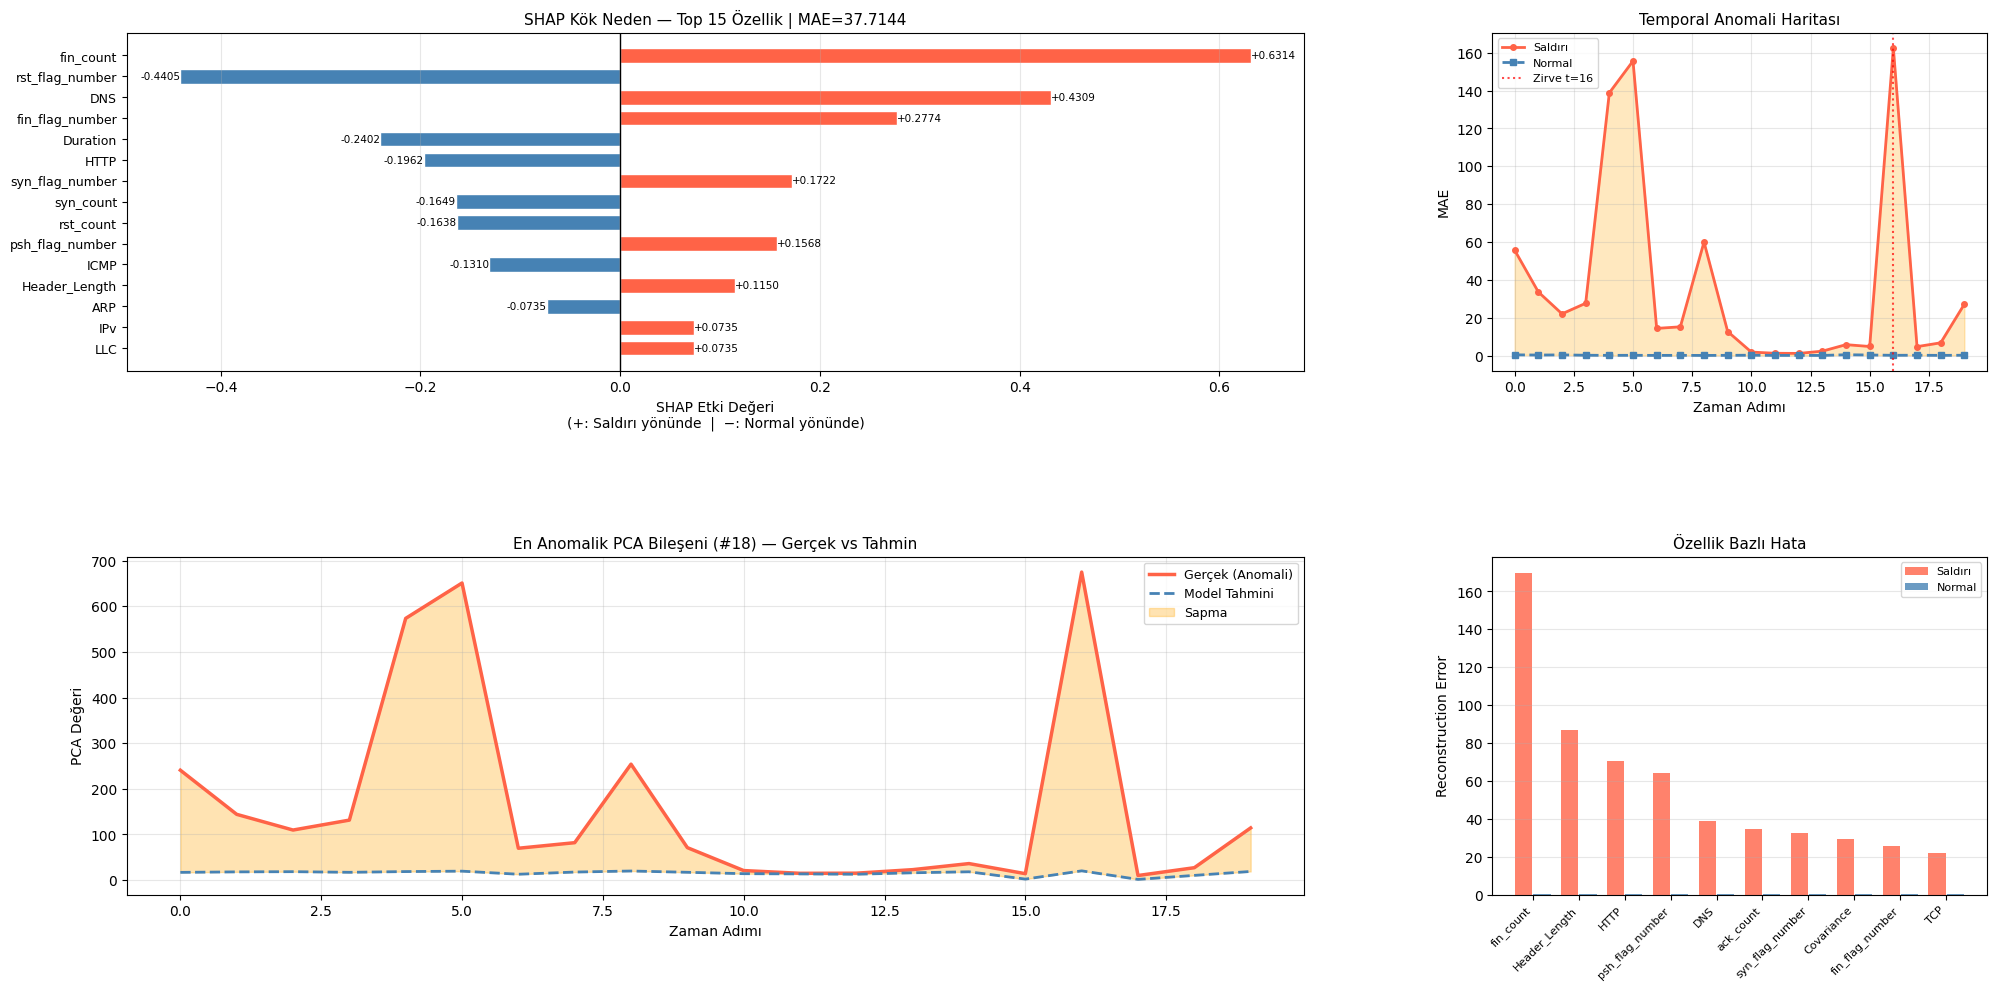

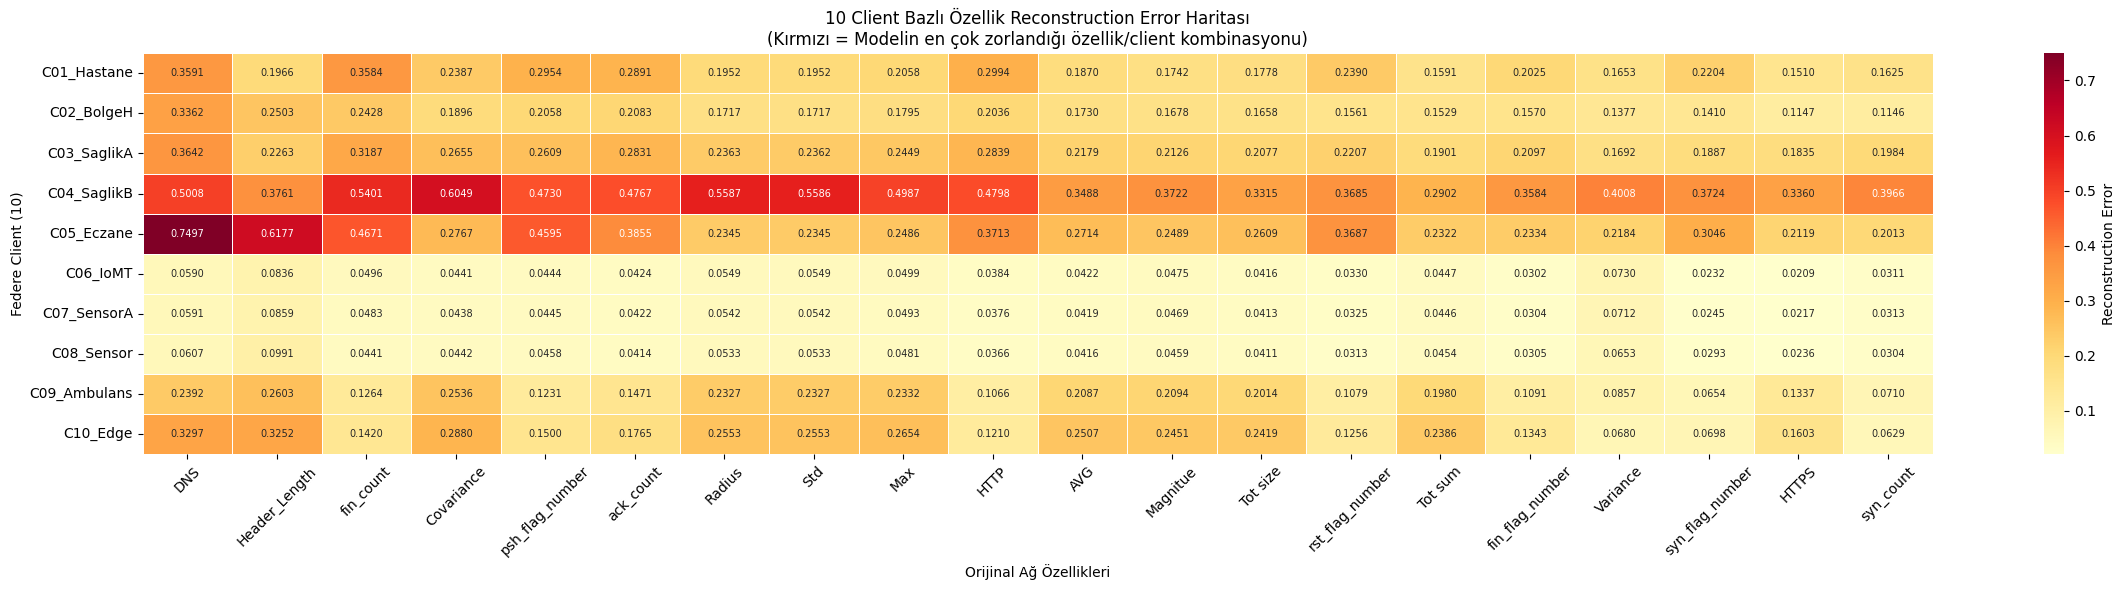

   -> Heatmap kaydedildi: federe_mha_xai_heatmap_10client.png


<Figure size 640x480 with 0 Axes>

   -> XAI panel kaydedildi: federe_mha_xai_panel_10client.png

   📋 KÖK NEDEN RAPORU — EN ŞİDDETLİ SALDIRI
   Dosya          : MQTT-DDoS-Publish_Flood_train.pcap.csv
   Anomali skoru  : 37.7144  (threshold'un 799.8x üstünde)
   Zirve zaman    : t=16/19

   Sıra  Özellik                               SHAP   Yön
   ────────────────────────────────────────────────────────────
   1     fin_count                      +0.631376   ↑ Saldırı
   2     rst_flag_number                -0.440478   ↓ Normal
   3     DNS                            +0.430931   ↑ Saldırı
   4     fin_flag_number                +0.277351   ↑ Saldırı
   5     Duration                       -0.240172   ↓ Normal
   6     HTTP                           -0.196197   ↓ Normal
   7     syn_flag_number                +0.172202   ↑ Saldırı
   8     syn_count                      -0.164899   ↓ Normal
   9     rst_count                      -0.163807   ↓ Normal
   10    psh_flag_number                +0.156810   ↑ Saldırı
   11    

In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 8: XAI ANALİZİ (10 CLIENT UYUMLU)
# =============================================================================
# Orijinal XAI pipeline korundu:
#   BÖLÜM A: SHAP KernelExplainer — Kök Neden Analizi
#   BÖLÜM B: Temporal Anomali Haritası
#   BÖLÜM C: Client Karşılaştırmalı Feature Analizi (10 Client)
#
# 10 Client uyarlaması:
#   - Background örneklem: 10 client'tan 10'ar = 100 background
#   - Client heatmap: 10×20 feature matrisi
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import gc
import os
import tensorflow as tf
import joblib
from tqdm import tqdm

print("=" * 65)
print("   XAI — AÇIKLANAB İLİR YZ ANALİZİ (10 CLIENT)")
print("=" * 65)

# BÖLÜM A: SHAP KÖK NEDEN ANALİZİ
print("\n" + "─"*65)
print("  BÖLÜM A: SHAP Kök Neden Analizi")
print("─"*65)

if len(attack_scores) == 0:
    print("   ⚠️  Saldırı verisi yok — SHAP analizi atlanıyor.")
    print("   ℹ️  Saldırı dosyaları eklendiğinde bu hücreyi tekrar çalıştırın.")
else:
    # En şiddetli saldırı paketleri
    top_attack_indices = np.argsort(attack_scores)[::-1][:5]
    print(f"   -> Top 5 anomali skoru: {[f'{s:.4f}' for s in attack_scores[top_attack_indices]]}")
    TARGET_IDX = top_attack_indices[0]

    # Hedef sequence dosyadan yükle
    expected_cols    = list(scaler.feature_names_in_)
    cumulative       = 0
    target_sequences = None
    target_file      = None

    for f in attack_files:
        try:
            df = pd.read_csv(f).select_dtypes(include=[np.number]).astype('float32')
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            df.dropna(inplace=True)
            if len(df) <= TIME_STEPS:
                continue
            for col in set(expected_cols) - set(df.columns):
                df[col] = 0.0
            df = df[expected_cols]
            n_seq = len(df) - TIME_STEPS
            if cumulative + n_seq > TARGET_IDX:
                scaled    = scaler.transform(df).astype(np.float32)
                pca_trans = pca.transform(scaled).astype(np.float32)
                seqs      = create_sequences_fast(pca_trans, TIME_STEPS)
                target_sequences = seqs
                target_file      = f
                del scaled, pca_trans
                break
            cumulative += n_seq
        except:
            continue

    print(f"   -> Kaynak dosya: {os.path.basename(target_file)}")

    preds_tmp   = global_model.predict(
        tf.data.Dataset.from_tensor_slices(target_sequences)
        .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE), verbose=0
    )
    mae_local     = np.mean(np.abs(target_sequences - preds_tmp), axis=(1,2))
    local_max_idx = np.argmax(mae_local)
    anomalous_seq = target_sequences[local_max_idx : local_max_idx+1]
    print(f"   -> Lokal en yüksek MAE: {mae_local[local_max_idx]:.4f}")

    del target_sequences, preds_tmp
    gc.collect()

    # SHAP Background: 10 client'ın her birinden 10 örnek (= 100 toplam)
    print("\n⚡ SHAP KernelExplainer — background 10×10=100 örnek...")
    time_steps_shap = TIME_STEPS
    pca_comps_shap  = PCA_COMPONENTS

    def predict_anomaly_score(X_flat):
        X_3d  = X_flat.reshape(-1, time_steps_shap, pca_comps_shap).astype(np.float32)
        ds    = (tf.data.Dataset.from_tensor_slices(X_3d)
                 .batch(256).prefetch(tf.data.AUTOTUNE))
        preds = global_model.predict(ds, verbose=0)
        mae   = np.mean(np.abs(X_3d - preds), axis=(1,2))
        return mae

    np.random.seed(SEED)
    bg_parts = []
    for client_info in CLIENT_DATASETS:  # 10 client
        all_x = np.concatenate([x.numpy() for x, _ in client_info["val"]], axis=0)
        idx   = np.random.choice(len(all_x), min(10, len(all_x)), replace=False)
        bg_parts.append(all_x[idx])
        del all_x

    bg_3d   = np.concatenate(bg_parts, axis=0)[:100]
    bg_flat = bg_3d.reshape(100, -1)
    del bg_parts
    gc.collect()

    print(f"   -> Background shape: {bg_flat.shape}")
    explainer    = shap.KernelExplainer(predict_anomaly_score, bg_flat)
    anomaly_flat = anomalous_seq[:, -TIME_STEPS:, :].reshape(1, -1)
    print("⏳ Shapley değerleri hesaplanıyor (~1-2 dk)...")
    shap_values  = explainer.shap_values(anomaly_flat, nsamples=200)

    # PCA Inverse Transform
    shap_3d   = np.array(shap_values).reshape(TIME_STEPS, PCA_COMPONENTS)
    shap_mean = np.mean(shap_3d, axis=0, keepdims=True)
    orig_shap = np.dot(shap_mean, pca.components_)
    shap_scores_orig = orig_shap[0]
    feature_names    = np.array(expected_cols)

    top_n     = 15
    top_idx   = np.argsort(np.abs(shap_scores_orig))[-top_n:][::-1]
    top_names = feature_names[top_idx]
    top_shap  = shap_scores_orig[top_idx]
    bar_colors = ['tomato' if s > 0 else 'steelblue' for s in top_shap]

# BÖLÜM B: TEMPORAL ANOMALİ HARİTASI
print("\n" + "─"*65)
print("  BÖLÜM B: Temporal Anomali Haritası")
print("─"*65)

if len(attack_scores) > 0:
    pred_anomaly = global_model.predict(anomalous_seq, verbose=0)
    pred_normal  = global_model.predict(bg_3d[:1], verbose=0)

    temporal_mae_anomaly = np.mean(np.abs(anomalous_seq[0] - pred_anomaly[0]), axis=1)
    temporal_mae_normal  = np.mean(np.abs(bg_3d[0] - pred_normal[0]), axis=1)
    feature_mae_anomaly  = np.mean(np.abs(anomalous_seq[0] - pred_anomaly[0]), axis=0)
    feature_mae_normal   = np.mean(np.abs(bg_3d[0] - pred_normal[0]), axis=0)
    feat_shap_anomaly    = np.dot(feature_mae_anomaly.reshape(1,-1), pca.components_)[0]
    feat_shap_normal     = np.dot(feature_mae_normal.reshape(1,-1),  pca.components_)[0]
    print(f"   -> Temporal MAE profili: {temporal_mae_anomaly.shape}")

# BÖLÜM C: 10 CLIENT KARŞILAŞTIRMALI XAI
print("\n" + "─"*65)
print("  BÖLÜM C: 10 Client Karşılaştırmalı Feature Analizi")
print("─"*65)

print("\n⚡ Her client için feature bazlı reconstruction error...")
client_feature_errors = {}
for client_info in CLIENT_DATASETS:
    cname   = client_info["name"]
    all_x   = np.concatenate([x.numpy() for x, _ in client_info["val"]], axis=0)
    idx     = np.random.choice(len(all_x), min(500, len(all_x)), replace=False)
    sample  = all_x[idx]
    preds   = global_model.predict(
        tf.data.Dataset.from_tensor_slices(sample)
        .batch(256).prefetch(tf.data.AUTOTUNE), verbose=0
    )
    feat_err_pca  = np.mean(np.abs(sample - preds), axis=(0,1))
    feat_err_orig = np.dot(feat_err_pca.reshape(1,-1), pca.components_)[0]
    client_feature_errors[cname] = feat_err_orig
    print(f"   -> {cname:>14}: mean_mae={np.mean(feat_err_pca):.5f}")
    del all_x, sample, preds
    gc.collect()

# GÖRSELLEŞTİRME
print("\n📈 XAI görselleştirme paneli (10 Client)...")

if len(attack_scores) > 0:
    fig = plt.figure(figsize=(24, 18))
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

    # SHAP Bar
    ax0 = fig.add_subplot(gs[0, :2])
    bars = ax0.barh(range(top_n), top_shap[::-1],
                    color=bar_colors[::-1], edgecolor='white', height=0.7)
    ax0.set_yticks(range(top_n))
    ax0.set_yticklabels(top_names[::-1], fontsize=9)
    ax0.axvline(0, color='black', linewidth=1)
    ax0.set_xlabel('SHAP Etki Değeri\n(+: Saldırı yönünde  |  −: Normal yönünde)', fontsize=10)
    ax0.set_title(f'SHAP Kök Neden — Top {top_n} Özellik | MAE={mae_local[local_max_idx]:.4f}', fontsize=11)
    ax0.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, top_shap[::-1]):
        ax0.text(val + (0.0002 if val >= 0 else -0.0002),
                 bar.get_y() + bar.get_height()/2,
                 f'{val:+.4f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=7.5)

    # Temporal
    ax1 = fig.add_subplot(gs[0, 2])
    ax1.plot(range(TIME_STEPS), temporal_mae_anomaly, 'tomato', linewidth=2, marker='o', markersize=4, label='Saldırı')
    ax1.plot(range(TIME_STEPS), temporal_mae_normal,  'steelblue', linewidth=2, linestyle='--', marker='s', markersize=4, label='Normal')
    ax1.fill_between(range(TIME_STEPS), temporal_mae_anomaly, temporal_mae_normal, alpha=0.25, color='orange')
    peak_t = np.argmax(temporal_mae_anomaly)
    ax1.axvline(peak_t, color='red', linestyle=':', alpha=0.7, label=f'Zirve t={peak_t}')
    ax1.set_xlabel('Zaman Adımı'); ax1.set_ylabel('MAE')
    ax1.set_title('Temporal Anomali Haritası', fontsize=11)
    ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

    # Gerçek vs Tahmin
    top1_pca = np.argmax(np.abs(shap_mean[0]))
    ax2 = fig.add_subplot(gs[1, :2])
    ax2.plot(anomalous_seq[0, :, top1_pca], 'tomato', linewidth=2.5, label='Gerçek (Anomali)')
    ax2.plot(pred_anomaly[0, :, top1_pca], 'steelblue', linewidth=2, linestyle='--', label='Model Tahmini')
    ax2.fill_between(range(TIME_STEPS),
                     anomalous_seq[0, :, top1_pca], pred_anomaly[0, :, top1_pca],
                     alpha=0.3, color='orange', label='Sapma')
    ax2.set_xlabel('Zaman Adımı'); ax2.set_ylabel('PCA Değeri')
    ax2.set_title(f'En Anomalik PCA Bileşeni (#{top1_pca}) — Gerçek vs Tahmin', fontsize=11)
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

    # Feature Anomali vs Normal
    top_feat_idx   = np.argsort(feat_shap_anomaly)[-10:][::-1]
    top_feat_names = feature_names[top_feat_idx]
    ax3 = fig.add_subplot(gs[1, 2])
    x_pos = np.arange(len(top_feat_idx))
    ax3.bar(x_pos-0.2, feat_shap_anomaly[top_feat_idx], width=0.38, color='tomato',    alpha=0.8, label='Saldırı')
    ax3.bar(x_pos+0.2, feat_shap_normal[top_feat_idx],  width=0.38, color='steelblue', alpha=0.8, label='Normal')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(top_feat_names, rotation=45, ha='right', fontsize=8)
    ax3.set_ylabel('Reconstruction Error'); ax3.set_title('Özellik Bazlı Hata', fontsize=11)
    ax3.legend(fontsize=8); ax3.grid(axis='y', alpha=0.3)

else:
    fig = plt.figure(figsize=(24, 8))
    gs  = gridspec.GridSpec(1, 1, figure=fig)
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.text(0.5, 0.5, 'SHAP & Temporal analiz için saldırı verisi gerekli',
             ha='center', va='center', fontsize=14, transform=ax0.transAxes)

# 10 Client Feature Error Heatmap — tüm figurlara eklenir
all_errs    = np.stack(list(client_feature_errors.values()), axis=0)  # (10, n_feat)
mean_errs   = np.mean(all_errs, axis=0)
top20_idx   = np.argsort(mean_errs)[-20:][::-1]
top20_names = feature_names[top20_idx]
cnames_list = list(client_feature_errors.keys())

# Heatmap ayrı figür olarak da kaydedilir (10 client genişlik için)
fig_hm, ax_hm = plt.subplots(figsize=(24, 6))
heatmap_data = pd.DataFrame(
    all_errs[:, top20_idx],
    index=cnames_list,
    columns=top20_names
)
sns.heatmap(heatmap_data, ax=ax_hm, cmap='YlOrRd',
            annot=True, fmt='.4f', annot_kws={'size': 7},
            linewidths=0.5, cbar_kws={'label': 'Reconstruction Error'})
ax_hm.set_title(
    '10 Client Bazlı Özellik Reconstruction Error Haritası\n'
    '(Kırmızı = Modelin en çok zorlandığı özellik/client kombinasyonu)',
    fontsize=12
)
ax_hm.set_xlabel('Orijinal Ağ Özellikleri', fontsize=10)
ax_hm.set_ylabel('Federe Client (10)', fontsize=10)
ax_hm.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('federe_mha_xai_heatmap_10client.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("   -> Heatmap kaydedildi: federe_mha_xai_heatmap_10client.png")

if len(attack_scores) > 0:
    plt.savefig('federe_mha_xai_panel_10client.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print("   -> XAI panel kaydedildi: federe_mha_xai_panel_10client.png")

    # KÖK NEDEN RAPORU
    print("\n" + "=" * 65)
    print("   📋 KÖK NEDEN RAPORU — EN ŞİDDETLİ SALDIRI")
    print("=" * 65)
    print(f"   Dosya          : {os.path.basename(target_file)}")
    print(f"   Anomali skoru  : {mae_local[local_max_idx]:.4f}  "
          f"(threshold'un {mae_local[local_max_idx]/DYNAMIC_THRESHOLD:.1f}x üstünde)")
    print(f"   Zirve zaman    : t={peak_t}/{TIME_STEPS-1}")
    print(f"\n   {'Sıra':<5} {'Özellik':<28} {'SHAP':>13}   Yön")
    print(f"   {'─'*60}")
    for i, (name, score) in enumerate(zip(top_names, top_shap)):
        yon = "↑ Saldırı" if score > 0 else "↓ Normal"
        print(f"   {i+1:<5} {name:<28} {score:>+11.6f}   {yon}")

# Drive'a XAI grafiklerini ekle
xai_files = ['federe_mha_xai_heatmap_10client.png', 'federe_mha_xai_panel_10client.png']
SAVE_DIR = '/content/drive/MyDrive/federe_mha_lstm_10client_outputs'
for fname in xai_files:
    src = f'/content/{fname}'
    if os.path.exists(src):
        shutil.copy2(src, f'{SAVE_DIR}/{fname}')
        print(f"   ✅ Drive'a kopyalandı: {fname}")

print("\n" + "=" * 65)
print("   HÜCRE 8 (XAI) TAMAMLANDI")
print("=" * 65)

In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 7: MODEL & ARTEFAKTLARı KAYDET + SONUÇ RAPORU
# =============================================================================
# 10 Client senaryosu için tam kayıt:
#   - Model (.keras)
#   - Scaler, PCA, Threshold (.pkl)
#   - Eğitim + Değerlendirme grafikleri (.png)
#   - Kapsamlı görselleştirme paneli
#   - Sunum özeti
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import joblib
import shutil
import os

print("=" * 65)
print("   SONUÇ RAPORU VE KAYIT (10 CLIENT)")
print("=" * 65)

# -- Model dosyasını kaydet
global_model.set_weights(best_weights)
global_model.save('federe_mha_lstm_10client_best.keras')
model_size_mb = os.path.getsize('federe_mha_lstm_10client_best.keras') / 1024 / 1024
print(f"\n✅ Model kaydedildi: federe_mha_lstm_10client_best.keras  ({model_size_mb:.1f} MB)")

# -- Threshold dosyaları
joblib.dump(DYNAMIC_THRESHOLD, 'federe_mha_threshold_f1_10client.pkl')
if len(attack_scores) > 0:
    joblib.dump(best_thresh_pr, 'federe_mha_threshold_pr_10client.pkl')
    print(f"✅ F1 threshold : {DYNAMIC_THRESHOLD:.5f}")
    print(f"✅ PR threshold : {best_thresh_pr:.5f}")

# 1. THRESHOLD KARŞILAŞTIRMASI
def evaluate_and_report(scores, labels, threshold, name):
    y_pred = (scores > threshold).astype(int)
    cm     = confusion_matrix(labels, y_pred)
    tn, fp, fn, tp = cm.ravel()
    report = classification_report(
        labels, y_pred,
        target_names=['Normal', 'Saldırı'],
        digits=4, output_dict=True
    )
    fpr_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f"\n  ▶ {name}  (threshold={threshold:.5f})")
    print(f"  {'─'*58}")
    print(f"  TP (Saldırı doğru)    : {tp:>12,}")
    print(f"  TN (Normal doğru)     : {tn:>12,}")
    print(f"  FP (Normal → Saldırı) : {fp:>12,}")
    print(f"  FN (Saldırı → Normal) : {fn:>12,}")
    print(f"  Accuracy              : %{report['accuracy']*100:.3f}")
    print(f"  Saldırı   F1          : %{report['Saldırı']['f1-score']*100:.3f}")
    print(f"  Saldırı   Recall      : %{report['Saldırı']['recall']*100:.3f}")
    print(f"  False Positive Rate   : %{fpr_rate*100:.3f}")
    return y_pred, cm, report

if len(attack_scores) > 0:
    print("\n📊 THRESHOLD KARŞILAŞTIRMASI")
    y_pred_f1, cm_f1, rep_f1 = evaluate_and_report(
        all_scores, all_labels, DYNAMIC_THRESHOLD, "F1-Optimize")
    y_pred_pr, cm_pr, rep_pr = evaluate_and_report(
        all_scores, all_labels, best_thresh_pr,   "PR-Optimize")

# 2. CLIENT İYİLEŞME TABLOSU
actual_rounds = len(history_rounds['val_loss'])
rounds_x      = range(1, actual_rounds + 1)

labels_10 = [
    'C01 Büyük Hastane', 'C02 Bölge Hastanesi', 'C03 Sağlık Ocağı A',
    'C04 Sağlık Ocağı B', 'C05 Eczane',
    'C06 IoMT Ana', 'C07 Sensör Kümesi', 'C08 Tekil Sensör',
    'C09 Ambulans', 'C10 Edge Router'
]

print("\n📊 CLIENT BAZLI EĞİTİM PERFORMANSI (10 CLIENT)")
print("─" * 68)
print(f"  {'Client':<22} | {'Round 1':>10} | {'Son Round':>10} | {'İyileşme':>10}")
print(f"  {'─'*22}-+-{'─'*10}-+-{'─'*10}-+-{'─'*10}")
for i, name in enumerate(labels_10):
    v_start = history_rounds['client_val'][i][0]
    v_end   = history_rounds['client_val'][i][-1]
    improv  = (v_start - v_end) / v_start * 100 if v_start > 0 else 0
    print(f"  {name:<22} | {v_start:>10.5f} | {v_end:>10.5f} | %{improv:>9.1f}")

# 3. KAPSAMLI PANEL (2×3)
colors_10 = [
    '#1565C0','#1976D2','#2196F3','#64B5F6','#BBDEFB',
    '#1B5E20','#388E3C','#81C784',
    '#E65100','#FF8F00'
]

fig = plt.figure(figsize=(22, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# (0,0) Global Train vs Val
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(rounds_x, history_rounds['train_loss'], 'b-o', markersize=3, linewidth=2, label='Train')
ax0.plot(rounds_x, history_rounds['val_loss'],   'r-s', markersize=3, linewidth=2, linestyle='--', label='Val')
ax0.axhline(best_val_loss, color='gray', linestyle=':', linewidth=1, label=f'Best={best_val_loss:.5f}')
ax0.set_title('Global Loss (Weighted FedAvg)', fontsize=11)
ax0.set_xlabel('Round'); ax0.set_ylabel('Loss')
ax0.legend(fontsize=9); ax0.grid(True, alpha=0.3)

# (0,1) Client Val Loss — WiFi grubu
ax1 = fig.add_subplot(gs[0, 1])
for i in range(5):  # WiFi
    ax1.plot(rounds_x, history_rounds['client_val'][i],
             color=colors_10[i], linewidth=1.8, label=labels_10[i].split(' ')[0]+' '+labels_10[i].split(' ')[1])
ax1.set_title('WiFi Client Grubu Val Loss (C01–C05)', fontsize=11)
ax1.set_xlabel('Round'); ax1.set_ylabel('Val Loss')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# (0,2) Client Val Loss — MQTT + Karma
ax2 = fig.add_subplot(gs[0, 2])
for i in range(5, 10):  # MQTT + Karma
    ax2.plot(rounds_x, history_rounds['client_val'][i],
             color=colors_10[i], linewidth=1.8, label=labels_10[i].split(' ')[0]+' '+labels_10[i].split(' ')[1])
ax2.set_title('MQTT+Karma Client Grubu Val Loss (C06–C10)', fontsize=11)
ax2.set_xlabel('Round'); ax2.set_ylabel('Val Loss')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# (1,0) Cosine LR
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(rounds_x, history_rounds['lr'], 'purple', linewidth=2)
ax3.set_title('Cosine Decay LR', fontsize=11)
ax3.set_xlabel('Round'); ax3.set_ylabel('LR')
ax3.set_yscale('log'); ax3.grid(True, alpha=0.3)

if len(attack_scores) > 0:
    # (1,1) Confusion Matrix
    ax4 = fig.add_subplot(gs[1, 1])
    sns.heatmap(cm_f1, annot=True, fmt='d', cmap='Blues', ax=ax4,
                xticklabels=['Normal','Saldırı'],
                yticklabels=['Normal','Saldırı'])
    ax4.set_title(f'CM F1-Optimize (t={DYNAMIC_THRESHOLD:.4f})', fontsize=11)
    ax4.set_ylabel('Gerçek'); ax4.set_xlabel('Tahmin')

    # (1,2) ROC Eğrisi
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'AUC={roc_auc:.4f}')
    ax5.plot([0,1],[0,1],'navy',lw=1,linestyle='--',alpha=0.5)
    ax5.set_xlabel('False Positive Rate'); ax5.set_ylabel('True Positive Rate')
    ax5.set_title('ROC Eğrisi', fontsize=11)
    ax5.legend(fontsize=9); ax5.grid(True, alpha=0.3)
else:
    # Normal skor dağılımı
    ax4 = fig.add_subplot(gs[1, 1:])
    ax4.hist(val_mae_normal, bins=80, color='steelblue', alpha=0.7,
             density=True, label='Normal Val MAE')
    ax4.axvline(DYNAMIC_THRESHOLD, color='red', linestyle='--', linewidth=2,
                label=f'Threshold={DYNAMIC_THRESHOLD:.4f}')
    ax4.set_xlabel('MAE'); ax4.set_ylabel('Yoğunluk')
    ax4.set_title('Normal MAE Dağılımı (Saldırı verisi yok)', fontsize=11)
    ax4.legend(); ax4.grid(True, alpha=0.3)

plt.suptitle(
    f'Federe MHA-LSTM Autoencoder — Tam Sonuç Paneli (10 Client)\n'
    f'{actual_rounds} Round | Weighted FedAvg | Cosine Decay'
    + (f' | AUC={roc_auc:.4f}' if len(attack_scores) > 0 and roc_auc else ''),
    fontsize=13, y=1.01
)
plt.savefig('federe_mha_sonuc_paneli_10client.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("   -> Grafik kaydedildi: federe_mha_sonuc_paneli_10client.png")

# 4. SUNUM ÖZETİ
print(f"""
================================================================
   📋 SUNUM ÖZETİ — FEDERE MHA-LSTM (10 CLIENT)
================================================================

  MİMARİ
  ├─ Model          : MHA-LSTM Hybrid Autoencoder (AYNI)
  ├─ Parametre      : {global_model.count_params():,}
  ├─ Clients        : {NUM_CLIENTS}  (↑ 5→10)
  ├─ Rounds         : {ROUNDS}  (aynı)
  ├─ Local Epochs   : {LOCAL_EPOCHS}  (aynı)
  ├─ Batch Size     : {BATCH_SIZE}  (aynı)
  ├─ LR Scheduler   : Cosine Decay (0.001 → 1e-6)
  └─ Best val_loss  : {best_val_loss:.5f}

  CLIENT GRUPLARI
  ├─ WiFi  (C01–C05) : Büyük Hastane → Eczane  (Non-IID: %40–%8)
  ├─ MQTT  (C06–C08) : IoMT Ana → Tekil Sensör (Non-IID: %50–%20)
  └─ Karma (C09–C10) : Ambulans + Edge Router  (WiFi+MQTT karma)
""")

if len(attack_scores) > 0 and roc_auc:
    print(f"""  PERFORMANS
  ├─ ROC AUC          : {roc_auc:.4f}
  ├─ F1-Opt Threshold : {DYNAMIC_THRESHOLD:.5f}
  └─ PR-Opt Threshold : {best_thresh_pr:.5f}""")

print("""
  KAYDEDILEN ARTEFAKTlar
  ├─ federe_mha_lstm_10client_best.keras
  ├─ federe_mha_scaler.pkl
  ├─ federe_mha_pca.pkl
  ├─ federe_mha_threshold_f1_10client.pkl
  ├─ federe_mha_threshold_pr_10client.pkl  (saldırı varsa)
  ├─ pca_varyans_analizi.png
  ├─ client_veri_dagilimi.png
  ├─ faz1_egitim_grafikleri_10client.png
  ├─ federe_mha_test_sonuclari_10client.png
  └─ federe_mha_sonuc_paneli_10client.png
================================================================
""")

# 5. DRIVE'A KAYDET
print("💾 Artifact'lar Drive'a kopyalanıyor...")
SAVE_DIR = '/content/drive/MyDrive/federe_mha_lstm_10client_outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

artifacts = [
    'federe_mha_lstm_10client_best.keras',
    'federe_mha_scaler.pkl',
    'federe_mha_pca.pkl',
    'federe_mha_threshold_f1_10client.pkl',
    'federe_mha_threshold_pr_10client.pkl',
    'pca_varyans_analizi.png',
    'client_veri_dagilimi.png',
    'faz1_egitim_grafikleri_10client.png',
    'federe_mha_test_sonuclari_10client.png',
    'federe_mha_sonuc_paneli_10client.png',
]

for fname in artifacts:
    src = f'/content/{fname}'
    dst = f'{SAVE_DIR}/{fname}'
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"   ✅ {fname}")
    else:
        print(f"   ⚠️  Bulunamadı (henüz oluşturulmadı): {fname}")

print("\n" + "=" * 65)
print("   🎉 TÜM HÜCRELER TAMAMLANDI")
print("   Federe MHA-LSTM (10 Client) başarıyla eğitildi.")
print("=" * 65)

   SONUÇ RAPORU VE KAYIT (10 CLIENT)

✅ Model kaydedildi: federe_mha_lstm_10client_best.keras  (5.8 MB)
✅ F1 threshold : 0.04716
✅ PR threshold : 0.20755

📊 THRESHOLD KARŞILAŞTIRMASI

  ▶ F1-Optimize  (threshold=0.04716)
  ──────────────────────────────────────────────────────────
  TP (Saldırı doğru)    :    8,664,716
  TN (Normal doğru)     :      192,597
  FP (Normal → Saldırı) :       21,400
  FN (Saldırı → Normal) :      108,857
  Accuracy              : %98.551
  Saldırı   F1          : %99.254
  Saldırı   Recall      : %98.759
  False Positive Rate   : %10.000

  ▶ PR-Optimize  (threshold=0.20755)
  ──────────────────────────────────────────────────────────
  TP (Saldırı doğru)    :    8,510,572
  TN (Normal doğru)     :      208,596
  FP (Normal → Saldırı) :        5,401
  FN (Saldırı → Normal) :      263,001
  Accuracy              : %97.014
  Saldırı   F1          : %98.448
  Saldırı   Recall      : %97.002
  False Positive Rate   : %2.524

📊 CLIENT BAZLI EĞİTİM PERFORMANSI (

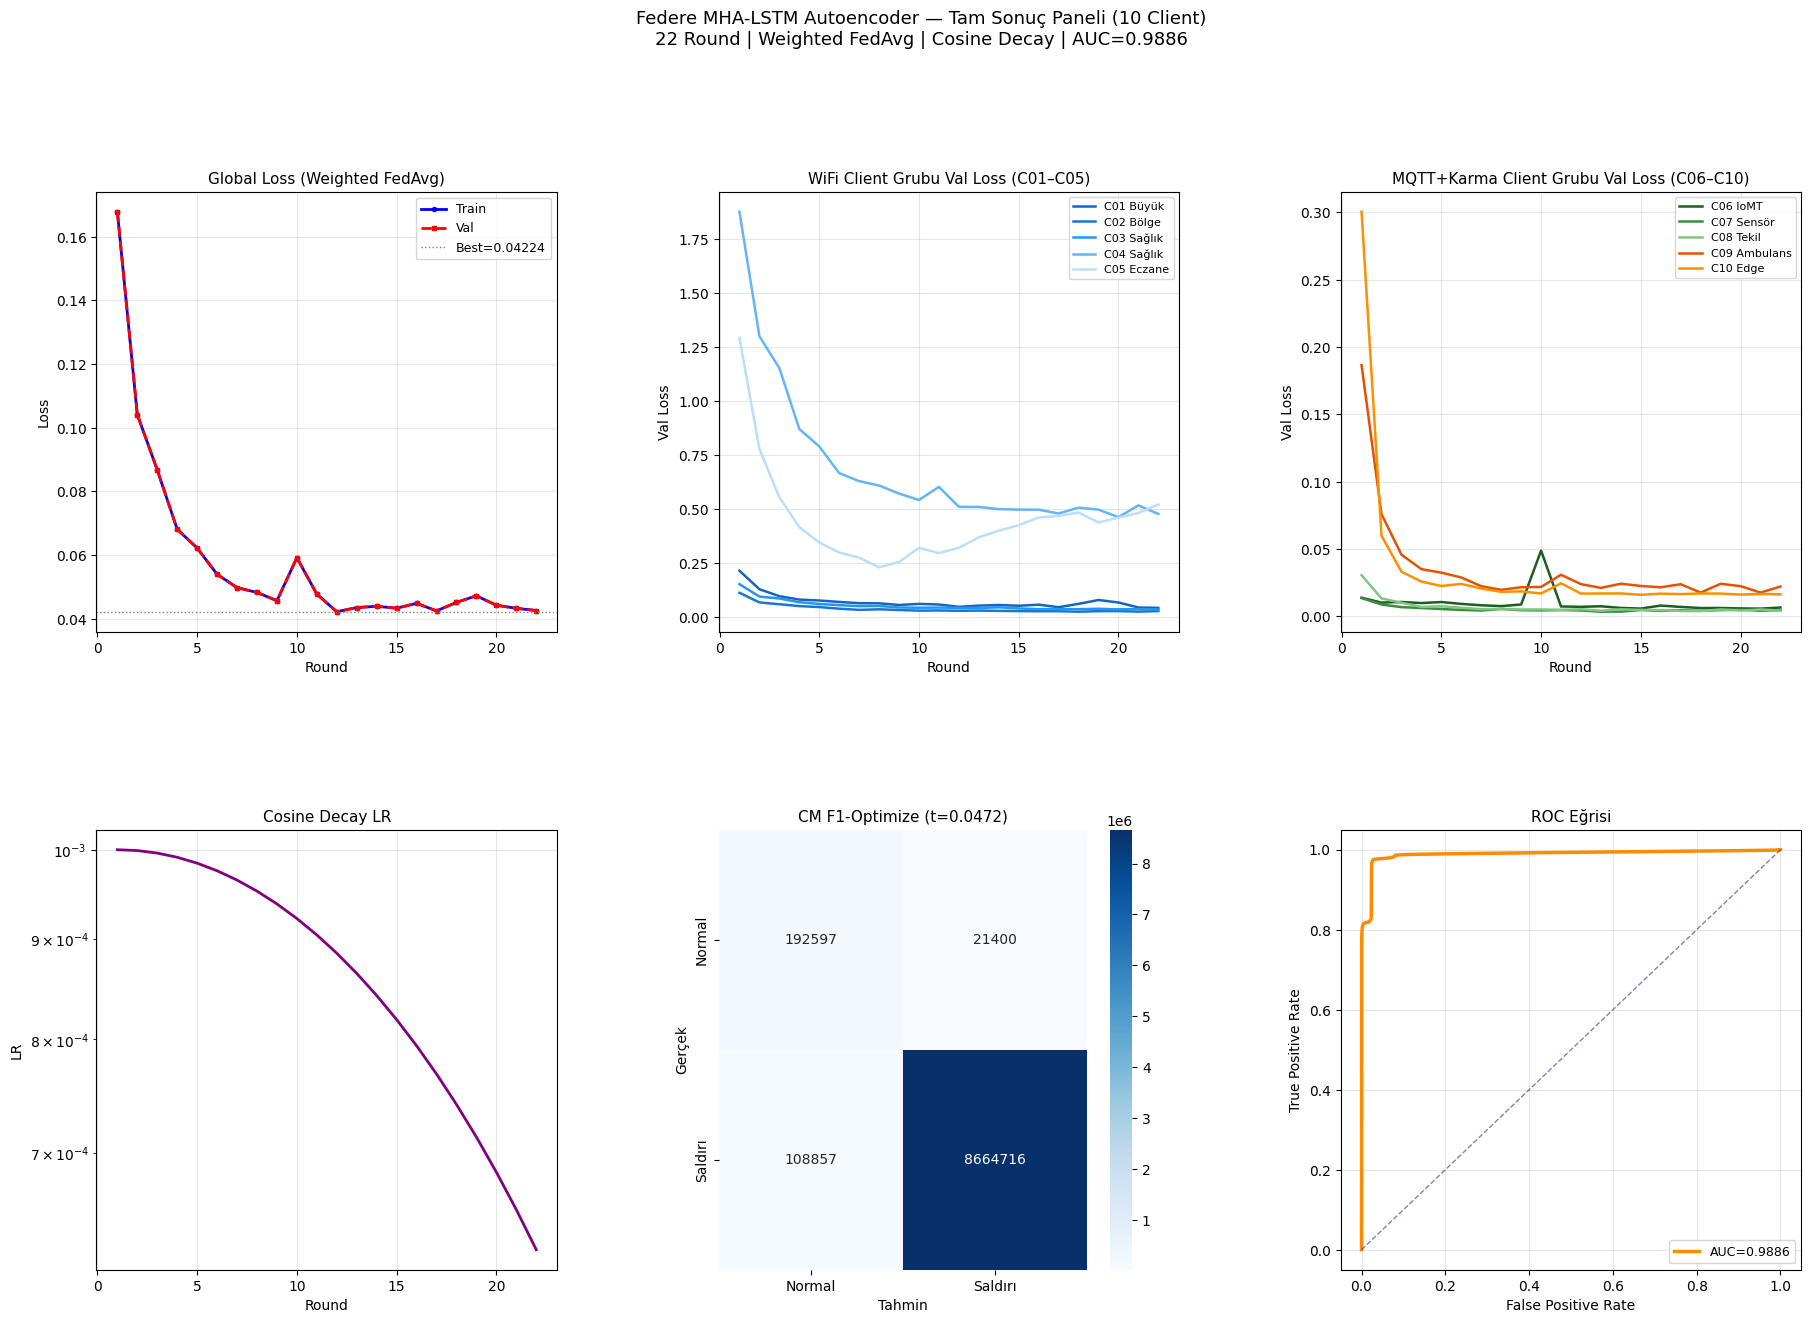

   -> Grafik kaydedildi: federe_mha_sonuc_paneli_10client.png

   📋 SUNUM ÖZETİ — FEDERE MHA-LSTM (10 CLIENT)

  MİMARİ
  ├─ Model          : MHA-LSTM Hybrid Autoencoder (AYNI)
  ├─ Parametre      : 1,475,092
  ├─ Clients        : 10  (↑ 5→10)
  ├─ Rounds         : 50  (aynı)
  ├─ Local Epochs   : 8  (aynı)
  ├─ Batch Size     : 512  (aynı)
  ├─ LR Scheduler   : Cosine Decay (0.001 → 1e-6)
  └─ Best val_loss  : 0.04224

  CLIENT GRUPLARI
  ├─ WiFi  (C01–C05) : Büyük Hastane → Eczane  (Non-IID: %40–%8)
  ├─ MQTT  (C06–C08) : IoMT Ana → Tekil Sensör (Non-IID: %50–%20)
  └─ Karma (C09–C10) : Ambulans + Edge Router  (WiFi+MQTT karma)

  PERFORMANS
  ├─ ROC AUC          : 0.9886
  ├─ F1-Opt Threshold : 0.04716
  └─ PR-Opt Threshold : 0.20755

  KAYDEDILEN ARTEFAKTlar
  ├─ federe_mha_lstm_10client_best.keras
  ├─ federe_mha_scaler.pkl
  ├─ federe_mha_pca.pkl
  ├─ federe_mha_threshold_f1_10client.pkl
  ├─ federe_mha_threshold_pr_10client.pkl  (saldırı varsa)
  ├─ pca_varyans_analizi.png
  ├─ 

In [ ]:
# =============================================================================
# FEDERE MHA-LSTM — HÜCRE 7: MODEL & ARTEFAKTLARı KAYDET + SONUÇ RAPORU
# =============================================================================
# 10 Client senaryosu için tam kayıt:
#   - Model (.keras)
#   - Scaler, PCA, Threshold (.pkl)
#   - Eğitim + Değerlendirme grafikleri (.png)
#   - Kapsamlı görselleştirme paneli
#   - Sunum özeti
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import joblib
import shutil
import os

print("=" * 65)
print("   SONUÇ RAPORU VE KAYIT (10 CLIENT)")
print("=" * 65)

# -- Model dosyasını kaydet
global_model.set_weights(best_weights)
global_model.save('federe_mha_lstm_10client_best.keras')
model_size_mb = os.path.getsize('federe_mha_lstm_10client_best.keras') / 1024 / 1024
print(f"\n✅ Model kaydedildi: federe_mha_lstm_10client_best.keras  ({model_size_mb:.1f} MB)")

# -- Threshold dosyaları
joblib.dump(DYNAMIC_THRESHOLD, 'federe_mha_threshold_f1_10client.pkl')
if len(attack_scores) > 0:
    joblib.dump(best_thresh_pr, 'federe_mha_threshold_pr_10client.pkl')
    print(f"✅ F1 threshold : {DYNAMIC_THRESHOLD:.5f}")
    print(f"✅ PR threshold : {best_thresh_pr:.5f}")

# 1. THRESHOLD KARŞILAŞTIRMASI
def evaluate_and_report(scores, labels, threshold, name):
    y_pred = (scores > threshold).astype(int)
    cm     = confusion_matrix(labels, y_pred)
    tn, fp, fn, tp = cm.ravel()
    report = classification_report(
        labels, y_pred,
        target_names=['Normal', 'Saldırı'],
        digits=4, output_dict=True
    )
    fpr_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f"\n  ▶ {name}  (threshold={threshold:.5f})")
    print(f"  {'─'*58}")
    print(f"  TP (Saldırı doğru)    : {tp:>12,}")
    print(f"  TN (Normal doğru)     : {tn:>12,}")
    print(f"  FP (Normal → Saldırı) : {fp:>12,}")
    print(f"  FN (Saldırı → Normal) : {fn:>12,}")
    print(f"  Accuracy              : %{report['accuracy']*100:.3f}")
    print(f"  Saldırı   F1          : %{report['Saldırı']['f1-score']*100:.3f}")
    print(f"  Saldırı   Recall      : %{report['Saldırı']['recall']*100:.3f}")
    print(f"  False Positive Rate   : %{fpr_rate*100:.3f}")
    return y_pred, cm, report

if len(attack_scores) > 0:
    print("\n📊 THRESHOLD KARŞILAŞTIRMASI")
    y_pred_f1, cm_f1, rep_f1 = evaluate_and_report(
        all_scores, all_labels, DYNAMIC_THRESHOLD, "F1-Optimize")
    y_pred_pr, cm_pr, rep_pr = evaluate_and_report(
        all_scores, all_labels, best_thresh_pr,   "PR-Optimize")

# 2. CLIENT İYİLEŞME TABLOSU
actual_rounds = len(history_rounds['val_loss'])
rounds_x      = range(1, actual_rounds + 1)

labels_10 = [
    'C01 Büyük Hastane', 'C02 Bölge Hastanesi', 'C03 Sağlık Ocağı A',
    'C04 Sağlık Ocağı B', 'C05 Eczane',
    'C06 IoMT Ana', 'C07 Sensör Kümesi', 'C08 Tekil Sensör',
    'C09 Ambulans', 'C10 Edge Router'
]

print("\n📊 CLIENT BAZLI EĞİTİM PERFORMANSI (10 CLIENT)")
print("─" * 68)
print(f"  {'Client':<22} | {'Round 1':>10} | {'Son Round':>10} | {'İyileşme':>10}")
print(f"  {'─'*22}-+-{'─'*10}-+-{'─'*10}-+-{'─'*10}")
for i, name in enumerate(labels_10):
    v_start = history_rounds['client_val'][i][0]
    v_end   = history_rounds['client_val'][i][-1]
    improv  = (v_start - v_end) / v_start * 100 if v_start > 0 else 0
    print(f"  {name:<22} | {v_start:>10.5f} | {v_end:>10.5f} | %{improv:>9.1f}")

# 3. KAPSAMLI PANEL (2×3)
colors_10 = [
    '#1565C0','#1976D2','#2196F3','#64B5F6','#BBDEFB',
    '#1B5E20','#388E3C','#81C784',
    '#E65100','#FF8F00'
]

fig = plt.figure(figsize=(22, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# (0,0) Global Train vs Val
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(rounds_x, history_rounds['train_loss'], 'b-o', markersize=3, linewidth=2, label='Train')
ax0.plot(rounds_x, history_rounds['val_loss'],   'r-s', markersize=3, linewidth=2, linestyle='--', label='Val')
ax0.axhline(best_val_loss, color='gray', linestyle=':', linewidth=1, label=f'Best={best_val_loss:.5f}')
ax0.set_title('Global Loss (Weighted FedAvg)', fontsize=11)
ax0.set_xlabel('Round'); ax0.set_ylabel('Loss')
ax0.legend(fontsize=9); ax0.grid(True, alpha=0.3)

# (0,1) Client Val Loss — WiFi grubu
ax1 = fig.add_subplot(gs[0, 1])
for i in range(5):  # WiFi
    ax1.plot(rounds_x, history_rounds['client_val'][i],
             color=colors_10[i], linewidth=1.8, label=labels_10[i].split(' ')[0]+' '+labels_10[i].split(' ')[1])
ax1.set_title('WiFi Client Grubu Val Loss (C01–C05)', fontsize=11)
ax1.set_xlabel('Round'); ax1.set_ylabel('Val Loss')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# (0,2) Client Val Loss — MQTT + Karma
ax2 = fig.add_subplot(gs[0, 2])
for i in range(5, 10):  # MQTT + Karma
    ax2.plot(rounds_x, history_rounds['client_val'][i],
             color=colors_10[i], linewidth=1.8, label=labels_10[i].split(' ')[0]+' '+labels_10[i].split(' ')[1])
ax2.set_title('MQTT+Karma Client Grubu Val Loss (C06–C10)', fontsize=11)
ax2.set_xlabel('Round'); ax2.set_ylabel('Val Loss')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# (1,0) Cosine LR
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(rounds_x, history_rounds['lr'], 'purple', linewidth=2)
ax3.set_title('Cosine Decay LR', fontsize=11)
ax3.set_xlabel('Round'); ax3.set_ylabel('LR')
ax3.set_yscale('log'); ax3.grid(True, alpha=0.3)

if len(attack_scores) > 0:
    # (1,1) Confusion Matrix
    ax4 = fig.add_subplot(gs[1, 1])
    sns.heatmap(cm_f1, annot=True, fmt='d', cmap='Blues', ax=ax4,
                xticklabels=['Normal','Saldırı'],
                yticklabels=['Normal','Saldırı'])
    ax4.set_title(f'CM F1-Optimize (t={DYNAMIC_THRESHOLD:.4f})', fontsize=11)
    ax4.set_ylabel('Gerçek'); ax4.set_xlabel('Tahmin')

    # (1,2) ROC Eğrisi
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'AUC={roc_auc:.4f}')
    ax5.plot([0,1],[0,1],'navy',lw=1,linestyle='--',alpha=0.5)
    ax5.set_xlabel('False Positive Rate'); ax5.set_ylabel('True Positive Rate')
    ax5.set_title('ROC Eğrisi', fontsize=11)
    ax5.legend(fontsize=9); ax5.grid(True, alpha=0.3)
else:
    # Normal skor dağılımı
    ax4 = fig.add_subplot(gs[1, 1:])
    ax4.hist(val_mae_normal, bins=80, color='steelblue', alpha=0.7,
             density=True, label='Normal Val MAE')
    ax4.axvline(DYNAMIC_THRESHOLD, color='red', linestyle='--', linewidth=2,
                label=f'Threshold={DYNAMIC_THRESHOLD:.4f}')
    ax4.set_xlabel('MAE'); ax4.set_ylabel('Yoğunluk')
    ax4.set_title('Normal MAE Dağılımı (Saldırı verisi yok)', fontsize=11)
    ax4.legend(); ax4.grid(True, alpha=0.3)

plt.suptitle(
    f'Federe MHA-LSTM Autoencoder — Tam Sonuç Paneli (10 Client)\n'
    f'{actual_rounds} Round | Weighted FedAvg | Cosine Decay'
    + (f' | AUC={roc_auc:.4f}' if len(attack_scores) > 0 and roc_auc else ''),
    fontsize=13, y=1.01
)
plt.savefig('federe_mha_sonuc_paneli_10client.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("   -> Grafik kaydedildi: federe_mha_sonuc_paneli_10client.png")

# 4. SUNUM ÖZETİ
print(f"""
================================================================
   📋 SUNUM ÖZETİ — FEDERE MHA-LSTM (10 CLIENT)
================================================================

  MİMARİ
  ├─ Model          : MHA-LSTM Hybrid Autoencoder (AYNI)
  ├─ Parametre      : {global_model.count_params():,}
  ├─ Clients        : {NUM_CLIENTS}  (↑ 5→10)
  ├─ Rounds         : {ROUNDS}  (aynı)
  ├─ Local Epochs   : {LOCAL_EPOCHS}  (aynı)
  ├─ Batch Size     : {BATCH_SIZE}  (aynı)
  ├─ LR Scheduler   : Cosine Decay (0.001 → 1e-6)
  └─ Best val_loss  : {best_val_loss:.5f}

  CLIENT GRUPLARI
  ├─ WiFi  (C01–C05) : Büyük Hastane → Eczane  (Non-IID: %40–%8)
  ├─ MQTT  (C06–C08) : IoMT Ana → Tekil Sensör (Non-IID: %50–%20)
  └─ Karma (C09–C10) : Ambulans + Edge Router  (WiFi+MQTT karma)
""")

if len(attack_scores) > 0 and roc_auc:
    print(f"""  PERFORMANS
  ├─ ROC AUC          : {roc_auc:.4f}
  ├─ F1-Opt Threshold : {DYNAMIC_THRESHOLD:.5f}
  └─ PR-Opt Threshold : {best_thresh_pr:.5f}""")

print("""
  KAYDEDILEN ARTEFAKTlar
  ├─ federe_mha_lstm_10client_best.keras
  ├─ federe_mha_scaler.pkl
  ├─ federe_mha_pca.pkl
  ├─ federe_mha_threshold_f1_10client.pkl
  ├─ federe_mha_threshold_pr_10client.pkl  (saldırı varsa)
  ├─ pca_varyans_analizi.png
  ├─ client_veri_dagilimi.png
  ├─ faz1_egitim_grafikleri_10client.png
  ├─ federe_mha_test_sonuclari_10client.png
  └─ federe_mha_sonuc_paneli_10client.png
================================================================
""")

# 5. DRIVE'A KAYDET
print("💾 Artifact'lar Drive'a kopyalanıyor...")
SAVE_DIR = '/content/drive/MyDrive/federe_mha_lstm_10client_outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

artifacts = [
    'federe_mha_lstm_10client_best.keras',
    'federe_mha_scaler.pkl',
    'federe_mha_pca.pkl',
    'federe_mha_threshold_f1_10client.pkl',
    'federe_mha_threshold_pr_10client.pkl',
    'pca_varyans_analizi.png',
    'client_veri_dagilimi.png',
    'faz1_egitim_grafikleri_10client.png',
    'federe_mha_test_sonuclari_10client.png',
    'federe_mha_sonuc_paneli_10client.png',
]

for fname in artifacts:
    src = f'/content/{fname}'
    dst = f'{SAVE_DIR}/{fname}'
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"   ✅ {fname}")
    else:
        print(f"   ⚠️  Bulunamadı (henüz oluşturulmadı): {fname}")

print("\n" + "=" * 65)
print("   🎉 TÜM HÜCRELER TAMAMLANDI")
print("   Federe MHA-LSTM (10 Client) başarıyla eğitildi.")
print("=" * 65)